In [1]:
import os 
import pandas as pd
import json
import requests
import time
from tqdm.auto import tqdm
from google import genai
from dotenv import load_dotenv
import pickle
import random


In [2]:

load_dotenv()
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

# Initialize Google Gemini client
client = genai.Client(api_key=GOOGLE_API_KEY)


In [3]:
food_df = pd.read_csv("food_df.csv", index_col=0)
food_df

,food_type,parsing_result,corrected_food,food_cluster,food_name_safe,food_embedding
0,b,nespresso,nespresso,13,nespresso,[ 3.01805420e-02 2.88329010e-02 -6.66379300e-...
1,f,oatmeal,oatmeal,70,oatmeal,[ 3.40316970e-02 4.60686000e-02 -3.08820880e-...
2,b,milk,milk,34,milk,[ 4.53863440e-02 1.91603790e-02 -5.22305370e-...
3,f,eggplant,eggplant,24,eggplant,[ 7.60755460e-03 -1.13470300e-02 -6.46341200e-...
4,f,lasagna,lasagna,45,lasagna,[ 1.77221450e-02 5.09285000e-03 -3.14315930e-...
...,...,...,...,...,...,...
2752,b,asahi vegan beer,asahi vegan beer,75,asahi_vegan_beer,[ 3.59883830e-02 4.74282900e-02 -6.40541540e-...
2753,f,eye round roast,eye of round roast,81,eye_of_round_roast,[ 4.94876430e-02 3.65882370e-02 -3.47454060e-...
2754,f,whey hydro isolate zero,whey hydrolysate isolate zero,65,whey_hydrolysate_isolate_zero,[ 4.68241240e-02 1.40685250e-02 -6.96792000e-...
2755,f,barukas,barukas,56,barukas,[ 3.69833900e-03 3.79980730e-02 -2.07108400e-...


In [4]:
food_df[['corrected_food', 'food_name_safe']]


,corrected_food,food_name_safe
0,nespresso,nespresso
1,oatmeal,oatmeal
2,milk,milk
3,eggplant,eggplant
4,lasagna,lasagna
...,...,...
2752,asahi vegan beer,asahi_vegan_beer
2753,eye of round roast,eye_of_round_roast
2754,whey hydrolysate isolate zero,whey_hydrolysate_isolate_zero
2755,barukas,barukas


In [5]:
usda_df = pd.read_csv("usda_classifications.csv", index_col=0)
usda_df

,usda_main_category,usda_sub_category,path
"4C Energy Rush Stix, Variety Pack",Beverages,Sweetened Beverages,food_info\4c_energy.json
Acai Berry,Fruit,Fruits,food_info\acai.json
Acai Bowl,Mixed Dishes,Mixed Dishes - Bean/Vegetable-based,food_info\acai_bowl.json
Acorn Squash,Vegetables,"Vegetables, excluding potatoes",food_info\acorn_squash.json
Actimel,Milk and Dairy,Dairy Drinks,food_info\actimel.json
...,...,...,...
Ziti,Grains,Cooked Grains,food_info\ziti.json
Zoodles,Vegetables,"Vegetables, excluding potatoes",food_info\zoodles.json
Zucchini,Vegetables,"Vegetables, excluding potatoes",food_info\zucchini.json
Zucchini Noodles,Vegetables,"Vegetables, excluding potatoes",food_info\zucchini_noodle.json


In [6]:
usda_cats = pd.read_csv("usda_categories.csv")
usda_cats

,Main Category,Secondary Category,Third Category
0,MILK AND DAIRY,Milk,"Milk, whole"
1,MILK AND DAIRY,Milk,"Milk, reduced fat"
2,MILK AND DAIRY,Milk,"Milk, lowfat"
3,MILK AND DAIRY,Milk,"Milk, nonfat"
4,MILK AND DAIRY,Flavored Milk,"Flavored milk, whole"
...,...,...,...
167,BABY FOODS AND FORMULAS,Infant Formulas,"Formula, ready-to-feed"
168,BABY FOODS AND FORMULAS,Infant Formulas,"Formula, prepared from powder"
169,BABY FOODS AND FORMULAS,Human Milk,Human milk
170,OTHER,Other,Protein and nutritional powders


In [7]:
usda_cats = usda_cats.reset_index()

In [ ]:
usda_cats.to_csv('usda_cats_df.csv')

In [8]:
usda_cats['Main Category'].unique()

array(['MILK AND DAIRY', 'PROTEIN FOODS', 'MIXED DISHES', 'GRAINS',
       'SNACKS AND SWEETS', 'FRUIT', 'VEGETABLES', 'BEVERAGES',
       'ALCOHOLIC BEVERAGES', 'WATER', 'FATS AND OILS',
       'CONDIMENTS AND SAUCES', 'SUGARS', 'BABY FOODS AND FORMULAS',
       'OTHER'], dtype=object)

In [10]:
usda_cats['Main Category'].value_counts()

Main Category
MIXED DISHES               29
VEGETABLES                 19
PROTEIN FOODS              18
SNACKS AND SWEETS          16
MILK AND DAIRY             15
BEVERAGES                  14
FRUIT                      13
GRAINS                     12
BABY FOODS AND FORMULAS    12
FATS AND OILS               6
CONDIMENTS AND SAUCES       6
WATER                       4
ALCOHOLIC BEVERAGES         3
SUGARS                      3
OTHER                       2
Name: count, dtype: int64

In [ ]:
from google import genai
from pydantic import BaseModel, Field
from typing import List, Literal
import os
import json
import time
import pandas as pd
from tqdm.auto import tqdm

# USDA Categories
USDACategory = Literal[
    'MILK AND DAIRY', 'PROTEIN FOODS', 'MIXED DISHES', 'GRAINS', 
    'SNACKS AND SWEETS', 'FRUIT', 'VEGETABLES', 'BEVERAGES', 
    'ALCOHOLIC BEVERAGES', 'WATER', 'FATS AND OILS', 
    'CONDIMENTS AND SAUCES', 'SUGARS', 'BABY FOODS AND FORMULAS', 'OTHER'
]

# Pydantic models
class FoodCategory(BaseModel):
    food_name: str = Field(description="Original food name")
    category_index: int = Field(description="Index of USDA main category (1-15)")
    usda_category: USDACategory = Field(description="Main USDA food category")

class BatchFoodCategories(BaseModel):
    categorized_foods: List[FoodCategory] = Field(description="List of categorized food items")

def categorize_foods(food_df, batch_size=100, fresh_start=True, output_dir="food_categories"):
    """
    Categorize foods in the dataframe according to USDA categories
    
    Args:
        food_df: DataFrame with 'corrected_food' column containing food names
        batch_size: Number of foods to process in each batch
        fresh_start: If True, ignore any previously processed foods
        output_dir: Directory to save results
    
    Returns:
        DataFrame with categorized foods
    """
    # Setup
    os.makedirs(output_dir, exist_ok=True)
    client = genai.Client(api_key=GOOGLE_API_KEY)
    tracking_path = os.path.join(output_dir, "processed_foods.json")
    
    # Get unique foods
    food_list = food_df['corrected_food'].unique().tolist()
    processed_foods = {}
    
    # Check for previously processed foods (unless fresh_start is True)
    if not fresh_start and os.path.exists(tracking_path):
        try:
            with open(tracking_path, 'r') as f:
                processed_foods = json.load(f)
            print(f"Found {len(processed_foods)} previously processed foods")
            food_list = [food for food in food_list if food not in processed_foods]
        except:
            print("Error reading tracking file, starting fresh")
    
    print(f"Processing {len(food_list)} foods in batches of {batch_size}")
    
    # Create batches and process
    batches = [food_list[i:i+batch_size] for i in range(0, len(food_list), batch_size)]
    results = []
    
    for i, batch in enumerate(tqdm(batches, desc="Processing batches")):
        # Format the food items for the prompt
        food_list_text = "\n".join([f"{i+1}. {food}" for i, food in enumerate(batch)])
        
        # Prepare prompt
        prompt = f"""
        Categorize each food item into EXACTLY ONE of these USDA food categories:
        
        1. MILK AND DAIRY
        2. PROTEIN FOODS
        3. MIXED DISHES
        4. GRAINS
        5. SNACKS AND SWEETS
        6. FRUIT
        7. VEGETABLES
        8. BEVERAGES
        9. ALCOHOLIC BEVERAGES
        10. WATER
        11. FATS AND OILS
        12. CONDIMENTS AND SAUCES
        13. SUGARS
        14. BABY FOODS AND FORMULAS
        15. OTHER
        
        Foods to categorize:
        {food_list_text}
        
        For each item, provide ONLY:
        1. The category index (1-15)
        2. The exact USDA category name as listed above
        """
        
        # Try to get response, with retry
        max_retries = 3
        for attempt in range(max_retries):
            try:
                response = client.models.generate_content(
                    model="gemini-2.0-flash",
                    contents=prompt,
                    config={
                        'response_mime_type': 'application/json',
                        'response_schema': BatchFoodCategories,
                        'system_instruction': 'You are a food categorization expert. Use only the exact USDA category names provided.',
                        'temperature': 1.0
                    }
                )
                
                batch_results = response.parsed.categorized_foods
                
                # Save batch results
                batch_id = int(time.time())
                with open(os.path.join(output_dir, f"batch_{batch_id}.json"), 'w') as f:
                    json.dump([r.model_dump() for r in batch_results], f, indent=2)
                
                # Update results and processed foods
                results.extend(batch_results)
                for item in batch_results:
                    processed_foods[item.food_name] = {
                        "category_index": item.category_index,
                        "usda_category": item.usda_category
                    }
                
                # Save progress
                with open(tracking_path, 'w') as f:
                    json.dump(processed_foods, f, indent=2)
                
                break  # Success, exit retry loop
                
            except Exception as e:
                if attempt < max_retries - 1:
                    wait_time = 2 ** attempt + 0.5
                    print(f"Error (attempt {attempt+1}/{max_retries}): {e}")
                    print(f"Retrying in {wait_time:.1f} seconds...")
                    time.sleep(wait_time)
                else:
                    print(f"Failed to categorize batch after {max_retries} attempts: {e}")
        
        # Uncomment to break after first batch (for testing)
        if i == 0: 
            print("Breaking after first batch for testing")
            break
    
    # Convert results to DataFrame
    if results:
        result_df = pd.DataFrame([r.model_dump() for r in results])
        
        # Merge with original DataFrame
        merged_df = food_df[['corrected_food', 'food_name_safe']].drop_duplicates()
        merged_df = merged_df.merge(
            result_df, 
            left_on='corrected_food', 
            right_on='food_name',
            how='inner'
        )
        
        # Save final results
        merged_df.to_csv(os.path.join(output_dir, "usda_categorized_foods.csv"), index=False)
        
        # Display summary
        print("\nSample of categorized foods:")
        print(merged_df[['corrected_food', 'category_index', 'usda_category']].head(10))
        
        category_counts = merged_df.groupby('usda_category').size().reset_index(name='count')
        category_counts = category_counts.sort_values('count', ascending=False)
        print("\nCategory distribution:")
        display(category_counts)
        
        return merged_df
    
    return pd.DataFrame()

# Example usage in notebook:
# categorized_foods = categorize_foods(food_df, batch_size=100, fresh_start=True)

In [ ]:
# from pydantic import BaseModel, Field
# from typing import List, Optional
# import os
# import json
# import time
# import pandas as pd
# from tqdm.auto import tqdm
#
# # Pydantic models for categorization
# class FoodCategoryDetailed(BaseModel):
#     food_name: str = Field(description="Original food name")
#     category_index: int = Field(description="Index from USDA categories (0-171)")
#     main_category: str = Field(description="Main USDA food category")
#     secondary_category: str = Field(description="Secondary USDA food category")
#     third_category: str = Field(description="Third USDA food category")
#
# class BatchFoodCategories(BaseModel):
#     categorized_foods: List[FoodCategoryDetailed] = Field(description="List of categorized food items")
#
# # ----------------------------------------------------------------
# # EXECUTION CODE STARTS HERE - NO FUNCTIONS
# # ----------------------------------------------------------------
#
# # Setup basics
# output_dir = "food_categories"
# os.makedirs(output_dir, exist_ok=True)
#
# # Take just one batch of foods to test
# batch_size = 100
# food_batch = food_df['corrected_food'].unique().tolist()[:batch_size]
# print(f"Processing {len(food_batch)} foods as a test batch")
#
# # Create category examples for the prompt
# category_examples = []
# for main in usda_cats['Main Category'].unique():
#     # Get just one secondary category for each main
#     sub_cats = usda_cats[usda_cats['Main Category'] == main]['Secondary Category'].unique()
#     if len(sub_cats) > 0:
#         sec = sub_cats[0]
#         # Get one example third category
#         thirds = usda_cats[(usda_cats['Main Category'] == main) &
#                            (usda_cats['Secondary Category'] == sec)]['Third Category']
#         if not thirds.empty:
#             third = thirds.iloc[0]
#             idx = usda_cats[(usda_cats['Main Category'] == main) &
#                            (usda_cats['Secondary Category'] == sec) &
#                            (usda_cats['Third Category'] == third)].index[0]
#             category_examples.append(f"{idx}: {main} | {sec} | {third}")
#
# categories_text = "\n".join(category_examples)
#
# # Format the food items for the prompt
# food_list_text = "\n".join([f"{j+1}. {food}" for j, food in enumerate(food_batch)])
#
# # Prepare the prompt
# prompt = f"""
# You are assigning foods to USDA food categories. The USDA uses a three-level categorization system.
#
# Here are examples from the USDA categories (index: Main | Secondary | Third):
# {categories_text}
#
# I have the full USDA category database with categories (indices 0-171).
#
# Categorize each of these foods according to the MOST SPECIFIC USDA category applicable:
# {food_list_text}
#
# For each food, provide:
# 1. The category index (0-171) that best matches
# 2. The exact Main Category name
# 3. The exact Secondary Category name
# 4. The exact Third Category name
#
# IMPORTANT: Use ONLY the EXACT category names from the USDA database - don't create new categories.
# Always prioritize choosing the correct Main and Secondary Category over getting the index exactly right.
# """
#
# # Make the request to Gemini
# max_retries = 3
# batch_results = []
#
# for attempt in range(max_retries):
#     try:
#         response = client.models.generate_content(
#             model="gemini-2.0-flash",
#             contents=prompt,
#             config={
#                 'response_mime_type': 'application/json',
#                 'response_schema': BatchFoodCategories,
#                 'system_instruction': 'You are a food categorization expert. Categorize foods according to the exact USDA categories. Do not create new categories.',
#                 'temperature': 0.0
#             }
#         )
#
#         batch_results = response.parsed.categorized_foods
#
#         # Save raw results to JSON exactly as received
#         batch_id = int(time.time())
#         raw_results_path = os.path.join(output_dir, f"raw_results_{batch_id}.json")
#         with open(raw_results_path, 'w') as f:
#             json.dump([r.model_dump() for r in batch_results], f, indent=2)
#
#         print(f"Saved raw results to {raw_results_path}")
#         break  # Success, exit retry loop
#
#     except Exception as e:
#         if attempt < max_retries - 1:
#             wait_time = 2 ** attempt + 0.5
#             print(f"Error (attempt {attempt+1}/{max_retries}): {e}")
#             print(f"Retrying in {wait_time:.1f} seconds...")
#             time.sleep(wait_time)
#         else:
#             print(f"Failed to categorize batch after {max_retries} attempts: {e}")


In [ ]:
from pydantic import BaseModel, Field
from typing import List, Optional
import os
import json
import time
import pandas as pd
from tqdm.auto import tqdm

# Pydantic models for categorization
class FoodCategoryDetailed(BaseModel):
    food_name: str = Field(description="Original food name")
    category_index: int = Field(description="Index from USDA categories (0-171)")
    main_category: str = Field(description="Main USDA food category")
    secondary_category: Optional[str] = Field(description="Secondary USDA food category")
    third_category: Optional[str] = Field(description="Third USDA food category")

class BatchFoodCategories(BaseModel):
    categorized_foods: List[FoodCategoryDetailed] = Field(description="List of categorized food items")

def categorize_foods_in_batches(food_df, usda_cats, client, batch_size=100, output_dir="food_categories"):
    """
    Categorize foods according to USDA categories, processing in batches
    
    Args:
        food_df: DataFrame with 'corrected_food' column containing food names
        usda_cats: DataFrame with USDA category hierarchy
        client: Initialized Gemini client
        batch_size: Number of foods to process in each batch
        output_dir: Directory to save results
        
    Returns:
        DataFrame with categorized foods
    """
    # Setup
    os.makedirs(output_dir, exist_ok=True)
    tracking_path = os.path.join(output_dir, "processed_foods.json")
    
    # Create CSV string of USDA categories once
    usda_categories_text = ",index,Main Category,Secondary Category,Third Category\n"  # Header
    for idx, row in usda_cats.iterrows():
        usda_categories_text += f"{idx},{idx},{row['Main Category']},{row['Secondary Category']},{row['Third Category']}\n"
    
    # Get unique foods
    food_list = food_df['corrected_food'].unique().tolist()
    print(f"Processing {len(food_list)} unique foods in batches of {batch_size}")
    
    # Check for previously processed foods
    processed_foods = {}
    if os.path.exists(tracking_path):
        try:
            with open(tracking_path, 'r') as f:
                processed_foods = json.load(f)
            print(f"Found {len(processed_foods)} previously processed foods")
            food_list = [food for food in food_list if food not in processed_foods]
            print(f"Remaining to process: {len(food_list)}")
        except:
            print("Error reading tracking file, starting fresh")
    
    # Create batches
    batches = [food_list[i:i+batch_size] for i in range(0, len(food_list), batch_size)]
    all_results = []
    
    # Process each batch
    for i, batch in enumerate(tqdm(batches, desc="Processing batches")):
        if not batch:  # Skip empty batches
            continue
            
        # Format the food items for the prompt
        food_list_text = "\n".join([f"{j+1}. {food}" for j, food in enumerate(batch)])
        
        # Create the prompt with the entire CSV
        prompt = f"""
        You are assigning foods to USDA food categories.

        Here is the complete USDA category database as a CSV:

        {usda_categories_text}

        Categorize each of these foods according to the MOST SPECIFIC USDA category in the CSV above:
        {food_list_text}

        For each food, provide:
        1. The exact index from the CSV (0-171)
        2. The exact Main Category name from the CSV
        3. The exact Secondary Category name from the CSV
        4. The exact Third Category name from the CSV

        IMPORTANT: Use ONLY the EXACT category names from the CSV above - don't create new categories.
        Your job is to match each food to the most appropriate category from this list.
        """
        
        # Try to get response, with retry
        max_retries = 3
        batch_results = []
        
        for attempt in range(max_retries):
            try:
                response = client.models.generate_content(
                    model="gemini-2.0-flash",
                    contents=prompt,
                    config={
                        'response_mime_type': 'application/json',
                        'response_schema': BatchFoodCategories,
                        'system_instruction': 'You are a food categorization expert. Categorize foods according to the exact USDA categories provided in the CSV. Do not create new categories.',
                        'temperature': 1.0
                    }
                )
                
                batch_results = response.parsed.categorized_foods
                
                # Save batch results
                batch_id = int(time.time())
                with open(os.path.join(output_dir, f"batch_{batch_id}.json"), 'w') as f:
                    json.dump([r.model_dump() for r in batch_results], f, indent=2)
                
                break  # Success, exit retry loop
                
            except Exception as e:
                if attempt < max_retries - 1:
                    wait_time = 2 ** attempt + 0.5
                    print(f"Error (attempt {attempt+1}/{max_retries}): {e}")
                    print(f"Retrying in {wait_time:.1f} seconds...")
                    time.sleep(wait_time)
                else:
                    print(f"Failed to categorize batch after {max_retries} attempts: {e}")
        
        # Process results
        if batch_results:
            # Add to our results collection
            all_results.extend(batch_results)
            
            # Update tracking of processed foods
            for item in batch_results:
                processed_foods[item.food_name] = {
                    "category_index": item.category_index,
                    "main_category": item.main_category,
                    "secondary_category": item.secondary_category,
                    "third_category": item.third_category
                }
            
            # Save updated tracking
            with open(tracking_path, 'w') as f:
                json.dump(processed_foods, f, indent=2)
        
        # Optional: Break after first batch for testing
        #if i == 0:
        #    print("Breaking after first batch for testing")
        #    break
    
    # Create final DataFrame
    if processed_foods:
        # Create rows from the processed foods dictionary
        result_rows = []
        for food_name, data in processed_foods.items():
            row = {'food_name': food_name}
            row.update(data)
            result_rows.append(row)
        
        # Create DataFrame
        result_df = pd.DataFrame(result_rows)
        
        # Merge with food_df
        merged_df = food_df[['corrected_food', 'food_name_safe']].drop_duplicates()
        final_df = merged_df.merge(
            result_df,
            left_on='corrected_food',
            right_on='food_name',
            how='inner'
        )
        
        # Save results
        final_df.to_csv(os.path.join(output_dir, "usda_categorized_foods.csv"), index=False)
        
        # Display summary
        print(f"\nCategorized {len(final_df)} foods")
        print("\nSample of categorized foods:")
        print(final_df[['corrected_food', 'category_index', 'main_category', 'secondary_category']].head(10))
        
        # Category distribution
        cat_counts = final_df.groupby('main_category').size().reset_index(name='count')
        cat_counts = cat_counts.sort_values('count', ascending=False)
        print("\nCategory distribution:")
        display(cat_counts)
        
        return final_df
    
    return pd.DataFrame()

# Example usage:
# categorized_foods = categorize_foods_in_batches(food_df, usda_cats, client, batch_size=100)

# food_cat_df = categorized_foods[['food_name', 'food_name_safe',
#                                  'main_category', 'secondary_category', 'third_category']]

# food_cat_df.to_csv('food_cat_df.csv')

In [11]:
food_cat_df = pd.read_csv('food_cat_df.csv',index_col=0)
food_cat_df

,food_name,food_name_safe,main_category,secondary_category,third_category
0,nespresso,nespresso,BEVERAGES,Coffee and Tea,Coffee
1,oatmeal,oatmeal,GRAINS,Cooked Cereals,Oatmeal
2,milk,milk,MILK AND DAIRY,Milk,"Milk, whole"
3,eggplant,eggplant,VEGETABLES,"Vegetables, excluding potatoes",Other vegetables and combinations
4,lasagna,lasagna,MIXED DISHES,Mixed Dishes – Grain-based,"Pasta mixed dishes, excludes macaroni & cheese"
...,...,...,...,...,...
2658,asahi vegan beer,asahi_vegan_beer,ALCOHOLIC BEVERAGES,Alcoholic Beverages,Beer
2659,eye of round roast,eye_of_round_roast,PROTEIN FOODS,Meats,"Beef, excludes ground"
2660,whey hydrolysate isolate zero,whey_hydrolysate_isolate_zero,OTHER,Other,Protein and nutritional powders
2661,barukas,barukas,PROTEIN FOODS,Plant-based Protein Foods,Nuts and seeds


In [12]:
user_items_df = pd.read_csv('/Users/vince/Salk/mCC_Analysis/data/compliant_user_items.csv')

# Load JSON file containing food corrections
with open('/Users/vince/Salk/mCC_Analysis/food_corrections.json', 'r') as f:
    food_corrections = json.load(f)

# Create a new column with corrected food names
user_items_df['corrected_food'] = user_items_df['parsing_result'].map(food_corrections).str.lower()

In [13]:
user_food_df = user_items_df[['pid',  'original_logtime',
        'time','corrected_food']]

user_food_df = user_food_df.rename(columns={'corrected_food' : 'food_name'})

In [14]:
user_food_df = user_food_df.merge(food_cat_df, how='inner')

In [15]:
user_food_df

,pid,original_logtime,time,food_name,food_name_safe,main_category,secondary_category,third_category
0,alqt150211047,2021-10-28 09:45:59,9.766389,nespresso,nespresso,BEVERAGES,Coffee and Tea,Coffee
1,alqt150211047,2021-10-28 09:45:59,9.766389,oatmeal,oatmeal,GRAINS,Cooked Cereals,Oatmeal
2,alqt150211047,2021-10-28 09:45:59,9.766389,milk,milk,MILK AND DAIRY,Milk,"Milk, whole"
3,alqt150211047,2021-10-28 11:57:00,11.950000,eggplant,eggplant,VEGETABLES,"Vegetables, excluding potatoes",Other vegetables and combinations
4,alqt150211047,2021-10-28 11:57:00,11.950000,lasagna,lasagna,MIXED DISHES,Mixed Dishes – Grain-based,"Pasta mixed dishes, excludes macaroni & cheese"
...,...,...,...,...,...,...,...,...
3184274,alqt230941256543,2023-09-21 16:32:00,16.533333,hibiscus tea,hibiscus_tea,BEVERAGES,Coffee and Tea,Tea
3184275,alqt230941256543,2023-09-21 16:32:00,16.533333,blueberry,blueberry,FRUIT,Fruits,Blueberries and other berries
3184276,alqt230941256543,2023-09-21 19:25:00,19.416667,baked chicken,baked_chicken,PROTEIN FOODS,Poultry,"Chicken, whole pieces"
3184277,alqt230941256543,2023-09-21 19:25:00,19.416667,mashed potato,mashed_potato,VEGETABLES,White Potatoes,Mashed potatoes and potato mixtures


# Visualizations



/var/folders/dv/lndb9rrs2kv2v5g8cyfyx0wr0000gn/T/ipykernel_75865/538438153.py:50: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




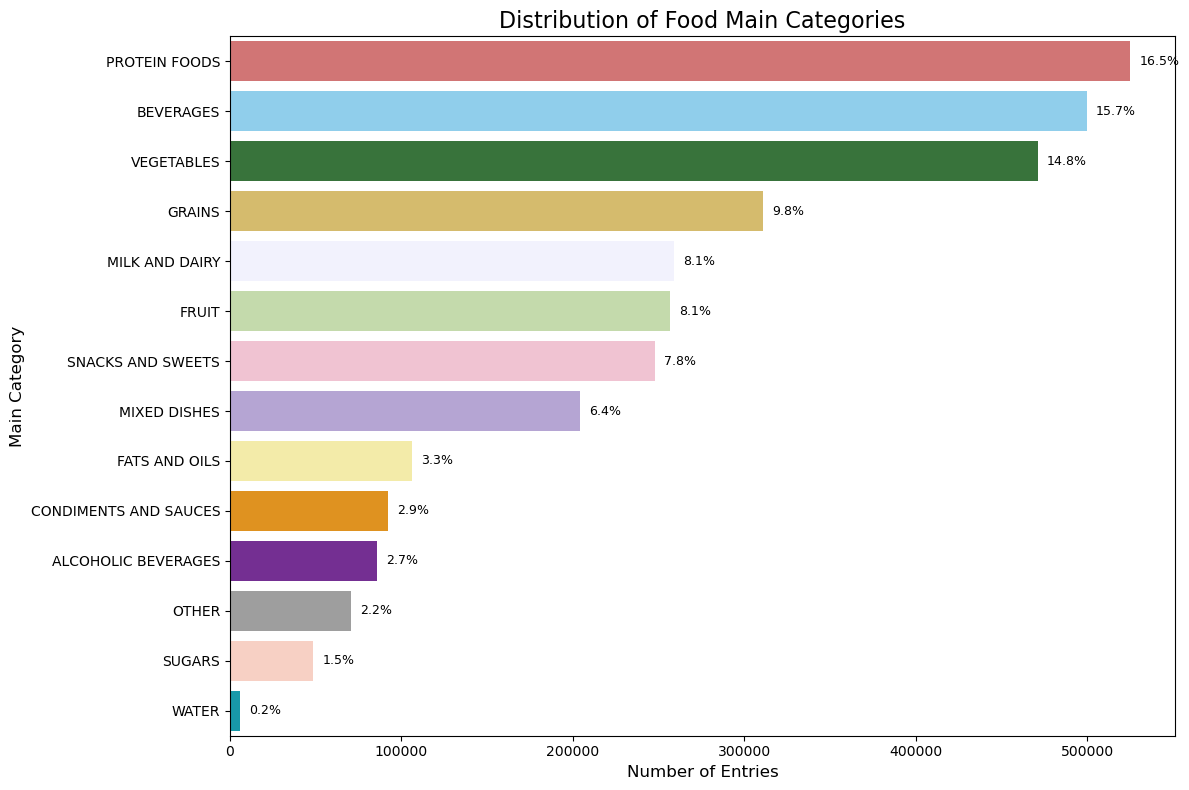


--- Resulting DataFrame with Counts ---
                 Category   Count  Percentage
0           PROTEIN FOODS  525187        16.5
1               BEVERAGES  499883        15.7
2              VEGETABLES  471075        14.8
3                  GRAINS  310796         9.8
4          MILK AND DAIRY  259161         8.1
5                   FRUIT  256868         8.1
6       SNACKS AND SWEETS  247995         7.8
7            MIXED DISHES  203999         6.4
8           FATS AND OILS  106279         3.3
9   CONDIMENTS AND SAUCES   92053         2.9
10    ALCOHOLIC BEVERAGES   85869         2.7
11                  OTHER   70425         2.2
12                 SUGARS   48609         1.5
13                  WATER    6080         0.2


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the custom color scheme provided by the user
custom_colors = {
    'MILK AND DAIRY': '#f0f0ff', 'PROTEIN FOODS': '#e06666', 'MIXED DISHES': '#b39ddb',
    'GRAINS': '#e6c35c', 'SNACKS AND SWEETS': '#f8bbd0', 'FRUIT': '#c5e1a5',
    'VEGETABLES': '#2e7d32', 'BEVERAGES': '#81d4fa', 'ALCOHOLIC BEVERAGES': '#7b1fa2',
    'WATER': '#00acc1', 'FATS AND OILS': '#fff59d', 'CONDIMENTS AND SAUCES': '#ff9800',
    'SUGARS': '#ffccbc', 'BABY FOODS AND FORMULAS': '#bcaaa4', 'OTHER': '#9e9e9e'
}
# Define a default color for any categories potentially missing from the map
default_color = '#CCCCCC' # A light gray

def plot_main_categories(df, color_lookup):
    """
    Create a horizontal bar chart of main categories using a specific color lookup.
    Ensures the dataframe of counts is built and used for plotting.

    Args:
        df (pd.DataFrame): The DataFrame containing the 'main_category' column.
                           Assumes this DataFrame is already loaded.
        color_lookup (dict): Dictionary mapping category names to color codes.
    """
    # --- Step 1: Calculate Counts and Percentages ---
    main_counts = df['main_category'].value_counts()
    total_entries = len(df)

    # --- Step 2: Create DataFrame with Counts ---
    # This DataFrame includes the 'Count' column, which determines bar lengths.
    main_df = pd.DataFrame({
        'Category': main_counts.index,
        'Count': main_counts.values,
        'Percentage': (main_counts.values / total_entries * 100).round(1)
    }).sort_values('Count', ascending=False) # Sorting by Count determines plot order

    # --- Step 3: Prepare the Custom Color Palette based on Sorted Categories ---
    # Get the category names in the order they will be plotted (sorted by count)
    ordered_categories = main_df['Category'].tolist()

    # Create the list of colors in the same order, using the provided lookup
    # Use .get() with a default color to handle categories not in the lookup
    ordered_palette = [color_lookup.get(category, default_color) for category in ordered_categories]

    # --- Step 4: Create the Bar Chart ---
    plt.figure(figsize=(12, 8))
    # Use x='Count' to ensure bar length represents the count
    # Use the generated 'ordered_palette' for colors
    ax = sns.barplot(x='Count', y='Category', data=main_df, palette=ordered_palette)

    # --- Step 5: Add Percentage Labels ---
    # Label position is based on 'Count'
    max_count = main_df['Count'].max() if not main_df.empty else 1
    label_offset = max_count * 0.01  # Offset relative to max count

    for i, row in enumerate(main_df.itertuples()):
        ax.text(row.Count + label_offset, i, f"{row.Percentage}%", va='center', ha='left', fontsize=9)

    # --- Step 6: Add Titles and Labels ---
    plt.title('Distribution of Food Main Categories', fontsize=16)
    plt.xlabel('Number of Entries', fontsize=12)
    plt.ylabel('Main Category', fontsize=12)
    plt.tight_layout()
    plt.show()

    # --- Step 7: Return the DataFrame ---
    # This returned DataFrame contains the 'Count' column.
    return main_df

# --- How to Use (Assuming 'user_food_df' is already loaded) ---

# Make sure your DataFrame 'user_food_df' exists and has the 'main_category' column
# Example:
# user_food_df = pd.read_csv('your_food_data.csv') # Or however you loaded it

# Now, call the function with your loaded DataFrame and the color dictionary:
main_df_result = plot_main_categories(user_food_df, custom_colors)

# The plot will be displayed, and main_df_result will hold the calculated counts/percentages
print("\n--- Resulting DataFrame with Counts ---")
print(main_df_result)

/var/folders/dv/lndb9rrs2kv2v5g8cyfyx0wr0000gn/T/ipykernel_75865/3105897080.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




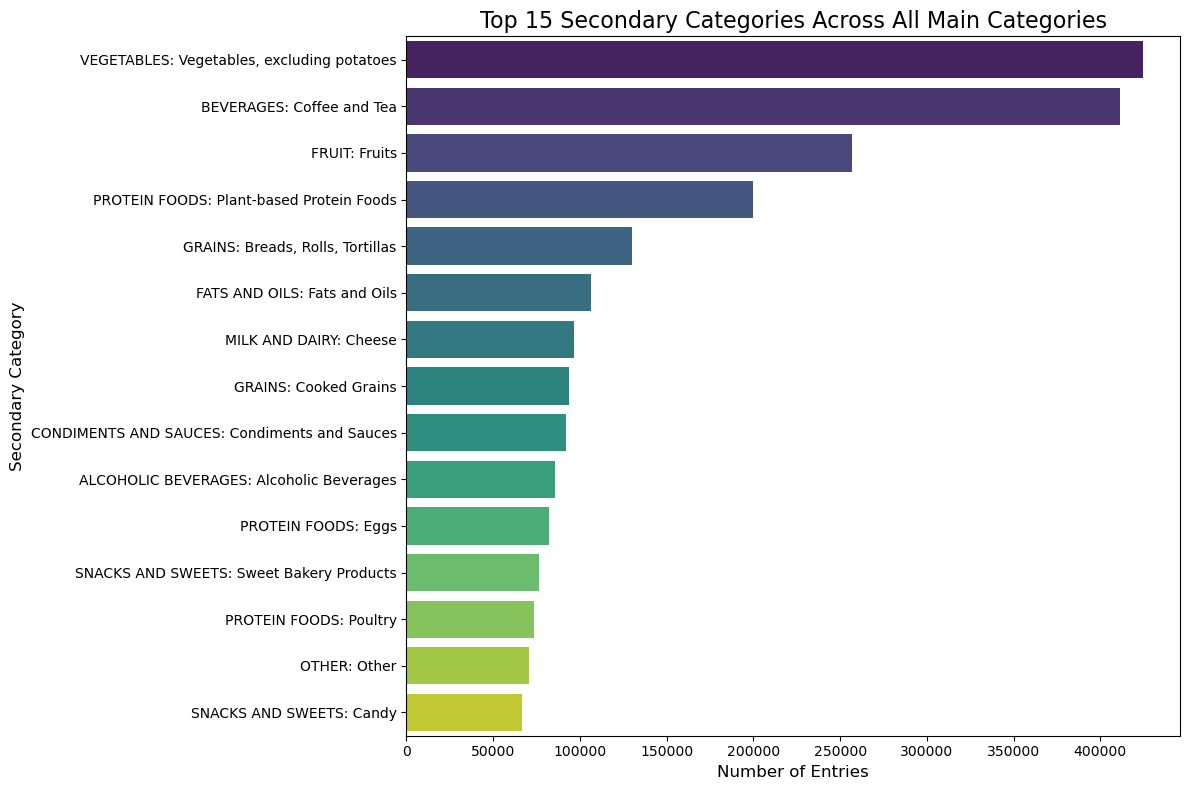

main_category          secondary_category            
VEGETABLES             Vegetables, excluding potatoes    424625
BEVERAGES              Coffee and Tea                    411377
FRUIT                  Fruits                            256868
PROTEIN FOODS          Plant-based Protein Foods         199745
GRAINS                 Breads, Rolls, Tortillas          129826
FATS AND OILS          Fats and Oils                     106279
MILK AND DAIRY         Cheese                             96871
GRAINS                 Cooked Grains                      93673
CONDIMENTS AND SAUCES  Condiments and Sauces              92053
ALCOHOLIC BEVERAGES    Alcoholic Beverages                85869
PROTEIN FOODS          Eggs                               82140
SNACKS AND SWEETS      Sweet Bakery Products              76363
PROTEIN FOODS          Poultry                            73400
OTHER                  Other                              70425
SNACKS AND SWEETS      Candy                      

In [23]:
def plot_secondary_categories(df, main_category=None, top_n=10):
    """
    Plot secondary categories for a specific main category or top secondary categories overall
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    if main_category:
        # Filter to just the specified main category
        filtered_df = df[df['main_category'] == main_category]
        secondary_counts = filtered_df['secondary_category'].value_counts().nlargest(top_n)
        title = f'Top {top_n} Secondary Categories in {main_category}'
    else:
        # Get combined main+secondary counts
        combined_counts = df.groupby(['main_category', 'secondary_category']).size()
        secondary_counts = combined_counts.nlargest(top_n)
        title = f'Top {top_n} Secondary Categories Across All Main Categories'
    
    # Create a DataFrame for plotting
    plot_df = pd.DataFrame({
        'Category': secondary_counts.index if main_category else [f"{idx[0]}: {idx[1]}" for idx in secondary_counts.index],
        'Count': secondary_counts.values
    })
    
    # Create a horizontal bar chart
    plt.figure(figsize=(12, 8))
    ax = sns.barplot(x='Count', y='Category', data=plot_df, palette='viridis')
    
    plt.title(title, fontsize=16)
    plt.xlabel('Number of Entries', fontsize=12)
    plt.ylabel('Secondary Category', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return secondary_counts  # Return for further analysis if needed

# # For a specific main category (e.g., VEGETABLES)
# secondary_counts = plot_secondary_categories(user_food_df, main_category="VEGETABLES", top_n=10)
# print(secondary_counts)

# Uncomment to run for top secondary categories across all main categories
secondary_counts_all = plot_secondary_categories(user_food_df, main_category=None, top_n=15)
print(secondary_counts_all)

In [46]:
user_food_df

,pid,original_logtime,time,food_name,food_name_safe,main_category,secondary_category,third_category
0,alqt150211047,2021-10-28 09:45:59,9.766389,nespresso,nespresso,BEVERAGES,Coffee and Tea,Coffee
1,alqt150211047,2021-10-28 09:45:59,9.766389,oatmeal,oatmeal,GRAINS,Cooked Cereals,Oatmeal
2,alqt150211047,2021-10-28 09:45:59,9.766389,milk,milk,MILK AND DAIRY,Milk,"Milk, whole"
3,alqt150211047,2021-10-28 11:57:00,11.950000,eggplant,eggplant,VEGETABLES,"Vegetables, excluding potatoes",Other vegetables and combinations
4,alqt150211047,2021-10-28 11:57:00,11.950000,lasagna,lasagna,MIXED DISHES,Mixed Dishes – Grain-based,"Pasta mixed dishes, excludes macaroni & cheese"
...,...,...,...,...,...,...,...,...
3184274,alqt230941256543,2023-09-21 16:32:00,16.533333,hibiscus tea,hibiscus_tea,BEVERAGES,Coffee and Tea,Tea
3184275,alqt230941256543,2023-09-21 16:32:00,16.533333,blueberry,blueberry,FRUIT,Fruits,Blueberries and other berries
3184276,alqt230941256543,2023-09-21 19:25:00,19.416667,baked chicken,baked_chicken,PROTEIN FOODS,Poultry,"Chicken, whole pieces"
3184277,alqt230941256543,2023-09-21 19:25:00,19.416667,mashed potato,mashed_potato,VEGETABLES,White Potatoes,Mashed potatoes and potato mixtures


In [47]:
user_food_df['third_category'].nunique()

154

In [18]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import textwrap
import os # Import os module for checking file existence

# ==============================================================================
# Function Definition: plot_flat_treemap_with_manual_legend
# (Paste the entire function code from your previous message here,
#  making sure the 'return fig' change from step 2 is included)
# ==============================================================================
def plot_flat_treemap_with_manual_legend(
    df,
    min_font_size=8,
    max_font_size=22,
    padding=1,
    legend_item_height = 0.04,
    legend_x_position = 0.98,
    legend_square_visual_height = 0.018 # Added from previous step
    ):
    """
    Create an interactive treemap showing ONLY third-level categories,
    colored by main category, with dynamic text sizing, white background,
    minimal gaps, and a static manual color legend sorted by count positioned
    tightly on the right. Root/parent nodes are hidden, and no extra axes/scales shown.

    Args:
        df (pd.DataFrame): Input dataframe with food log data.
        min_font_size (int): Minimum font size for text in the smallest boxes (>=1).
        max_font_size (int): Maximum font size for text in the largest boxes.
        padding (int): Padding around each box. Lower values reduce gaps.
        legend_item_height (float): Controls center-to-center vertical distance between legend items.
        legend_x_position (float): Starting X coordinate (paper ref) for the legend shapes.
        legend_square_visual_height (float): Fixed visual height of the color square in the legend.
    """
    min_font_size = max(1, min_font_size)

    custom_colors = { # Ensure your full map is here
        'MILK AND DAIRY': '#f0f0ff', 'PROTEIN FOODS': '#e06666', 'MIXED DISHES': '#b39ddb',
        'GRAINS': '#e6c35c', 'SNACKS AND SWEETS': '#f8bbd0', 'FRUIT': '#c5e1a5',
        'VEGETABLES': '#2e7d32', 'BEVERAGES': '#81d4fa', 'ALCOHOLIC BEVERAGES': '#7b1fa2',
        'WATER': '#00acc1', 'FATS AND OILS': '#fff59d', 'CONDIMENTS AND SAUCES': '#ff9800',
        'SUGARS': '#ffccbc', 'BABY FOODS AND FORMULAS': '#bcaaa4', 'OTHER': '#9e9e9e'
    }

    required_cols = ['main_category', 'secondary_category', 'third_category', 'food_name']
     # --- Robust DataFrame Check ---
    if df is None:
         raise ValueError("Input DataFrame 'df' cannot be None.")
    if not isinstance(df, pd.DataFrame):
         raise ValueError("Input 'df' must be a pandas DataFrame.")
    if df.empty:
         print("Warning: Input DataFrame 'df' is empty.")
         return go.Figure().update_layout(title_text="No data to display") # Return empty fig
    if not all(col in df.columns for col in required_cols):
        missing_cols = [col for col in required_cols if col not in df.columns]
        raise ValueError(f"Dataframe missing required columns: {missing_cols}")


    # --- Data Prep (Filter third level) ---
    try:
        grouped_counts = df.groupby(['main_category', 'secondary_category', 'third_category'], observed=True).size().reset_index(name='count')
        unique_items = df.groupby(['main_category', 'secondary_category', 'third_category'], observed=True)['food_name'].nunique().reset_index(name='unique_items')
    except KeyError as e:
         print(f"KeyError during groupby: Make sure columns {required_cols} exist and are spelled correctly.")
         raise e
    except Exception as e:
         print(f"An unexpected error occurred during groupby: {e}")
         raise e

    grouped = pd.merge(grouped_counts, unique_items, on=['main_category', 'secondary_category', 'third_category'])
    grouped = grouped[grouped['third_category'].notna() & (grouped['third_category'] != '')].copy()
    grouped = grouped[grouped['count'] > 0]

    if grouped.empty:
        print("Warning: No valid third-level category data found after filtering.")
        return go.Figure().update_layout(title_text="No valid third-level data to display") # Return empty fig

    # --- Calculate Main Category Counts for Sorting Legend ---
    main_category_counts = df['main_category'].value_counts()
    present_main_cats = grouped['main_category'].unique()
    sorted_legend_cats = main_category_counts[main_category_counts.index.isin(present_main_cats)].index.tolist()
    legend_colors_sorted = {cat: custom_colors[cat] for cat in sorted_legend_cats if cat in custom_colors}


    # --- Font Size Calculation ---
    log_counts = np.log1p(grouped['count'])
    min_log_count = log_counts.min()
    max_log_count = log_counts.max()
    if max_log_count > min_log_count:
        normalized_size = (log_counts - min_log_count) / (max_log_count - min_log_count)
        grouped['font_size'] = min_font_size + normalized_size * (max_font_size - min_font_size)
    else:
        grouped['font_size'] = (min_font_size + max_font_size) / 2
    grouped['font_size'] = grouped['font_size'].round().astype(int).clip(lower=1)


    # --- Path ID and Mapping ---
    root_node_name = "All Foods"
    grouped['path_id'] = root_node_name + '/' + grouped['main_category'] + '/' + grouped['secondary_category'] + '/' + grouped['third_category']
    id_to_fontsize = pd.Series(grouped['font_size'].values, index=grouped['path_id']).to_dict()
    id_to_unique_items = pd.Series(grouped['unique_items'].values, index=grouped['path_id']).to_dict()


    # --- Build the Initial Hierarchical Treemap ---
    px_fig = px.treemap(
        grouped,
        path=[px.Constant(root_node_name), 'main_category', 'secondary_category', 'third_category'],
        values='count',
        color='main_category',
        color_discrete_map=custom_colors,
        custom_data=['unique_items']
    )

    # --- Extract and Modify the Treemap Trace ---
    treemap_trace = px_fig.data[0]
    trace_ids = list(treemap_trace.ids)
    trace_labels = list(treemap_trace.labels)
    trace_marker_colors = list(treemap_trace.marker.colors) if hasattr(treemap_trace.marker, 'colors') and treemap_trace.marker.colors is not None else ['#808080'] * len(trace_ids)

    final_font_sizes = []
    final_labels_for_trace = []
    final_marker_line_widths = []
    final_hover_templates = []
    wrap_width = 18
    root_node_index = -1

    for i, current_id in enumerate(trace_ids):
        original_label = trace_labels[i]
        is_target_leaf_node = current_id in id_to_fontsize
        is_root_node = current_id == root_node_name

        if is_root_node:
            root_node_index = i

        if is_target_leaf_node:
            font_size = id_to_fontsize[current_id]
            final_font_sizes.append(font_size)
            final_marker_line_widths.append(0.5)
            if len(original_label) > wrap_width:
                wrapped_label = "<br>".join(textwrap.wrap(original_label, width=wrap_width, break_long_words=True))
            else:
                wrapped_label = original_label
            final_labels_for_trace.append(wrapped_label)

            unique_items_val = id_to_unique_items.get(current_id, 0)
            hover_label = original_label
            final_hover_templates.append(f"<b>{hover_label}</b><br>Path: %{{id}}<br><br>Count: %{{value:,.0f}}<br>Unique Items: {unique_items_val:,.0f}<extra></extra>")

        else: # Hide root and parents
            final_font_sizes.append(1)
            final_labels_for_trace.append('')
            final_marker_line_widths.append(0)
            final_hover_templates.append("<extra></extra>")

    # Force Root Node Color to White
    if root_node_index != -1 and len(trace_marker_colors) > root_node_index:
        trace_marker_colors[root_node_index] = 'rgba(255, 255, 255, 1)' # Force white

    # Apply modifications DIRECTLY to the trace object
    treemap_trace.update(
        insidetextfont=dict(family="Arial, sans-serif", size=final_font_sizes),
        labels=final_labels_for_trace,
        texttemplate="<b>%{label}</b><br>C: %{value:,.0f}<br>U: %{customdata[0]:,.0f}",
        hovertemplate=final_hover_templates,
        textposition="top left",
        marker=dict(
            colors=trace_marker_colors, # Apply modified colors list
            line=dict(width=final_marker_line_widths, color='white'),
            depthfade=False,
            pad=dict(t=padding, l=padding, r=padding, b=padding)
        )
    )

    # --- Create Single Plot Figure ---
    fig = go.Figure(data=[treemap_trace])

    # --- Manually Create Legend using Shapes and Annotations ---
    legend_shapes = []
    legend_annotations = []

    title_y_pos = 0.98
    legend_annotations.append(
        go.layout.Annotation(
            x=legend_x_position, y=title_y_pos, xref="paper", yref="paper",
            text="<b>Main Category</b>", showarrow=False, align='left',
            xanchor='left', font=dict(size=12)
        )
    )
    current_y = title_y_pos - (legend_item_height * 1.0)
    shape_width = 0.015
    text_x_offset = 0.005

    for cat in sorted_legend_cats:
        color = legend_colors_sorted[cat]
        shape_y0 = current_y - (legend_square_visual_height / 2)
        shape_y1 = current_y + (legend_square_visual_height / 2)
        legend_shapes.append(
            go.layout.Shape(
                type="rect", xref="paper", yref="paper",
                x0=legend_x_position, y0=shape_y0,
                x1=legend_x_position + shape_width, y1=shape_y1,
                fillcolor=color, line=dict(width=0.5, color='grey')
            )
        )
        legend_annotations.append(
            go.layout.Annotation(
                x=legend_x_position + shape_width + text_x_offset, y=current_y,
                xref="paper", yref="paper", text=cat, showarrow=False, align='left',
                xanchor='left', yanchor='middle', font=dict(size=10)
            )
        )
        current_y -= legend_item_height


    # --- Update Overall Layout ---
    fig.update_layout(
        title=dict(
            text='<b>Food Categories</b>',
            font=dict(size=22), x=0.5, xanchor='center'
            ),
        margin=dict(t=50, l=10, r=200, b=10),
        width=1200, height=800,
        font=dict(family="Arial, sans-serif"),
        paper_bgcolor='white',
        plot_bgcolor='white',
        showlegend=False,
        xaxis=dict(showticklabels=False, showgrid=False, zeroline=False, visible=False),
        yaxis=dict(showticklabels=False, showgrid=False, zeroline=False, visible=False),
        coloraxis_showscale=False,
        shapes=legend_shapes,
        annotations=legend_annotations
    )

    # fig.show() # Keep this if you still want to see the interactive plot
    return fig # Return the figure object

# --- Example Usage ---
try:
    # Make sure user_food_df is loaded correctly before calling
    if 'user_food_df' not in locals() or not isinstance(user_food_df, pd.DataFrame) or user_food_df.empty:
         raise NameError("DataFrame 'user_food_df' is not defined, not a DataFrame, or is empty.")

    # --- Create the figure ---
    fig = plot_flat_treemap_with_manual_legend( # Assign the returned figure to 'fig'
        user_food_df,
        min_font_size=8,
        max_font_size=24,
        padding=1,
        legend_item_height=0.04,
        legend_x_position=1.01,
        legend_square_visual_height=0.018
    )

    # --- Save the figure ---
    if fig: # Check if the figure was created successfully
        output_filename_png = "food_treemap_high_res.png"
        output_filename_svg = "food_treemap.svg"
        output_filename_pdf = "food_treemap.pdf"
        scale_factor = 3 # Increase this for higher resolution PNG (e.g., 3, 4, 5)

        print(f"Attempting to save figure...")
        # Save as PNG (high-resolution raster)
        try:
            fig.write_image(output_filename_png, scale=scale_factor)
            print(f"Successfully saved PNG: {os.path.abspath(output_filename_png)}")
        except Exception as e:
            print(f"Error saving PNG: {e}")
            print("Ensure 'kaleido' is installed (pip install -U kaleido)")

        # Save as SVG (vector format - infinitely scalable)
        try:
            fig.write_image(output_filename_svg)
            print(f"Successfully saved SVG: {os.path.abspath(output_filename_svg)}")
        except Exception as e:
            print(f"Error saving SVG: {e}")

        # Save as PDF (vector format)
        try:
            fig.write_image(output_filename_pdf)
            print(f"Successfully saved PDF: {os.path.abspath(output_filename_pdf)}")
        except Exception as e:
            print(f"Error saving PDF: {e}")

    else:
        print("Figure object was not created (likely due to empty data). Skipping save.")


except ValueError as e:
    print(f"ValueError creating plot: {e}")
except NameError as e:
    print(f"NameError: {e}") # Make sure the DF exists
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    import traceback
    traceback.print_exc()

Attempting to save figure...
Successfully saved PNG: /Users/vince/Salk/mCC_Analysis/food_treemap_high_res.png
Successfully saved SVG: /Users/vince/Salk/mCC_Analysis/food_treemap.svg
Successfully saved PDF: /Users/vince/Salk/mCC_Analysis/food_treemap.pdf


In [ ]:
clusters = pd.read_csv("kmeans_5_user_clusters.csv")

In [135]:
user_food_cluster_df = user_food_df.merge(clusters)

In [142]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import textwrap
import os

def create_food_treemap(
    df,
    min_font_size=8,
    max_font_size=22,
    padding=1,
    legend_item_height=0.04,
    legend_x_position=1.02,
    legend_square_visual_height=0.018,
    output_png=None,
    output_svg=None,
    output_pdf=None,
    title=None,
    scale_factor=3
    ):
    """
    Create and save an interactive treemap showing third-level food categories.
    
    Args:
        df (pd.DataFrame): Input dataframe with food log data.
        min_font_size (int): Minimum font size for text in the smallest boxes.
        max_font_size (int): Maximum font size for text in the largest boxes.
        padding (int): Padding around each box. Lower values reduce gaps.
        legend_item_height (float): Controls vertical distance between legend items.
        legend_x_position (float): Starting X coordinate for the legend.
        legend_square_visual_height (float): Fixed height of color squares in legend.
        output_png (str, optional): Filename to save PNG output.
        output_svg (str, optional): Filename to save SVG output.
        output_pdf (str, optional): Filename to save PDF output.
        scale_factor (int): Resolution multiplier for PNG export.
        
    Returns:
        go.Figure: The created treemap figure
    """
    # Ensure minimum font size is at least 1
    min_font_size = max(1, min_font_size)

    # Color mapping for main categories
    custom_colors = {
        'MILK AND DAIRY': '#f0f0ff', 'PROTEIN FOODS': '#e06666', 'MIXED DISHES': '#b39ddb',
        'GRAINS': '#e6c35c', 'SNACKS AND SWEETS': '#f8bbd0', 'FRUIT': '#c5e1a5',
        'VEGETABLES': '#2e7d32', 'BEVERAGES': '#81d4fa', 'ALCOHOLIC BEVERAGES': '#7b1fa2',
        'WATER': '#00acc1', 'FATS AND OILS': '#fff59d', 'CONDIMENTS AND SAUCES': '#ff9800',
        'SUGARS': '#ffccbc', 'BABY FOODS AND FORMULAS': '#bcaaa4', 'OTHER': '#9e9e9e'
    }

    # Basic validation
    required_cols = ['main_category', 'secondary_category', 'third_category', 'food_name']
    if not all(col in df.columns for col in required_cols):
        missing_cols = [col for col in required_cols if col not in df.columns]
        raise ValueError(f"Dataframe missing required columns: {missing_cols}")

    # Data preparation - group by categories and count instances
    grouped_counts = df.groupby(['main_category', 'secondary_category', 'third_category'], observed=True).size().reset_index(name='count')
    unique_items = df.groupby(['main_category', 'secondary_category', 'third_category'], observed=True)['food_name'].nunique().reset_index(name='unique_items')
    
    # Merge counts with unique item counts
    grouped = pd.merge(grouped_counts, unique_items, on=['main_category', 'secondary_category', 'third_category'])
    
    # Filter for valid third categories with counts > 0
    grouped = grouped[grouped['third_category'].notna() & (grouped['third_category'] != '')].copy()
    grouped = grouped[grouped['count'] > 0]

    # Return empty figure if no data
    if grouped.empty:
        return go.Figure().update_layout(title_text="No valid third-level data to display")

    # Calculate main category counts for legend sorting
    main_category_counts = df['main_category'].value_counts()
    present_main_cats = grouped['main_category'].unique()
    sorted_legend_cats = main_category_counts[main_category_counts.index.isin(present_main_cats)].index.tolist()
    legend_colors_sorted = {cat: custom_colors.get(cat, '#9e9e9e') for cat in sorted_legend_cats}

    # Calculate font sizes based on logarithmic counts
    log_counts = np.log1p(grouped['count'])
    min_log_count = log_counts.min()
    max_log_count = log_counts.max()
    
    if max_log_count > min_log_count:
        normalized_size = (log_counts - min_log_count) / (max_log_count - min_log_count)
        grouped['font_size'] = min_font_size + normalized_size * (max_font_size - min_font_size)
    else:
        grouped['font_size'] = (min_font_size + max_font_size) / 2
        
    grouped['font_size'] = grouped['font_size'].round().astype(int).clip(lower=1)

    # Create path IDs for treemap hierarchy
    root_node_name = "All Foods"
    grouped['path_id'] = root_node_name + '/' + grouped['main_category'] + '/' + grouped['secondary_category'] + '/' + grouped['third_category']
    id_to_fontsize = pd.Series(grouped['font_size'].values, index=grouped['path_id']).to_dict()
    id_to_unique_items = pd.Series(grouped['unique_items'].values, index=grouped['path_id']).to_dict()

    # Build the initial hierarchical treemap
    px_fig = px.treemap(
        grouped,
        path=[px.Constant(root_node_name), 'main_category', 'secondary_category', 'third_category'],
        values='count',
        color='main_category',
        color_discrete_map=custom_colors,
        custom_data=['unique_items']
    )

    # Extract and modify the treemap trace
    treemap_trace = px_fig.data[0]
    trace_ids = list(treemap_trace.ids)
    trace_labels = list(treemap_trace.labels)
    trace_marker_colors = list(treemap_trace.marker.colors) if hasattr(treemap_trace.marker, 'colors') and treemap_trace.marker.colors is not None else ['#808080'] * len(trace_ids)

    # Prepare display properties for each node
    final_font_sizes = []
    final_labels_for_trace = []
    final_marker_line_widths = []
    final_hover_templates = []
    wrap_width = 18
    root_node_index = -1

    for i, current_id in enumerate(trace_ids):
        original_label = trace_labels[i]
        is_target_leaf_node = current_id in id_to_fontsize
        is_root_node = current_id == root_node_name

        if is_root_node:
            root_node_index = i

        if is_target_leaf_node:
            # Configure leaf node (actual data node)
            font_size = id_to_fontsize[current_id]
            final_font_sizes.append(font_size)
            final_marker_line_widths.append(0.5)
            
            # Wrap text if needed
            if len(original_label) > wrap_width:
                wrapped_label = "<br>".join(textwrap.wrap(original_label, width=wrap_width, break_long_words=True))
            else:
                wrapped_label = original_label
            final_labels_for_trace.append(wrapped_label)

            # Create hover template
            unique_items_val = id_to_unique_items.get(current_id, 0)
            hover_label = original_label
            final_hover_templates.append(
                f"<b>{hover_label}</b><br>Path: %{{id}}<br><br>Count: %{{value:,.0f}}<br>Unique Items: {unique_items_val:,.0f}<extra></extra>"
            )
        else:
            # Hide parent nodes
            final_font_sizes.append(1)
            final_labels_for_trace.append('')
            final_marker_line_widths.append(0)
            final_hover_templates.append("<extra></extra>")

    # Force root node color to white
    if root_node_index != -1 and len(trace_marker_colors) > root_node_index:
        trace_marker_colors[root_node_index] = 'rgba(255, 255, 255, 1)'

    # Apply all modifications to the trace
    treemap_trace.update(
        insidetextfont=dict(family="Arial, sans-serif", size=final_font_sizes),
        labels=final_labels_for_trace,
        texttemplate="<b>%{label}</b><br>C: %{value:,.0f}<br>U: %{customdata[0]:,.0f}",
        hovertemplate=final_hover_templates,
        textposition="top left",
        marker=dict(
            colors=trace_marker_colors,
            line=dict(width=final_marker_line_widths, color='white'),
            depthfade=False,
            pad=dict(t=padding, l=padding, r=padding, b=padding)
        )
    )

    # Create the figure with the modified trace
    fig = go.Figure(data=[treemap_trace])

    # Create manual legend with shapes and annotations
    legend_shapes = []
    legend_annotations = []

    # Add legend title
    title_y_pos = 0.98
    legend_annotations.append(
        go.layout.Annotation(
            x=legend_x_position, y=title_y_pos, xref="paper", yref="paper",
            text="<b>Main Category</b>", showarrow=False, align='left',
            xanchor='left', font=dict(size=12)
        )
    )
    
    # Add legend items
    current_y = title_y_pos - (legend_item_height * 1.0)
    shape_width = 0.015
    text_x_offset = 0.005

    for cat in sorted_legend_cats:
        color = legend_colors_sorted[cat]
        shape_y0 = current_y - (legend_square_visual_height / 2)
        shape_y1 = current_y + (legend_square_visual_height / 2)
        
        # Add colored square
        legend_shapes.append(
            go.layout.Shape(
                type="rect", xref="paper", yref="paper",
                x0=legend_x_position, y0=shape_y0,
                x1=legend_x_position + shape_width, y1=shape_y1,
                fillcolor=color, line=dict(width=0.5, color='grey')
            )
        )
        
        # Add category text
        legend_annotations.append(
            go.layout.Annotation(
                x=legend_x_position + shape_width + text_x_offset, y=current_y,
                xref="paper", yref="paper", text=cat, showarrow=False, align='left',
                xanchor='left', yanchor='middle', font=dict(size=10)
            )
        )
        current_y -= legend_item_height

    if not title: title = 'Food Categories'

    # Update overall layout
    fig.update_layout(
        title=dict(
            text=f"<b>{title}</b>",
            font=dict(size=22), x=0.5, xanchor='center'
        ),
        margin=dict(t=50, l=10, r=200, b=10),
        width=1200, height=800,
        font=dict(family="Arial, sans-serif"),
        paper_bgcolor='white',
        plot_bgcolor='white',
        showlegend=False,
        xaxis=dict(showticklabels=False, showgrid=False, zeroline=False, visible=False),
        yaxis=dict(showticklabels=False, showgrid=False, zeroline=False, visible=False),
        coloraxis_showscale=False,
        shapes=legend_shapes,
        annotations=legend_annotations
    )

    # Save the figure in requested formats
    if output_png:
        try:
            fig.write_image(output_png, scale=scale_factor)
        except Exception as e:
            print(f"Error saving PNG: {e}")
    
    if output_svg:
        try:
            fig.write_image(output_svg)
        except Exception as e:
            print(f"Error saving SVG: {e}")
    
    if output_pdf:
        try:
            fig.write_image(output_pdf)
        except Exception as e:
            print(f"Error saving PDF: {e}")

    return fig

# Example usage:
fig = create_food_treemap(
    user_food_df, 
    # output_png="food_treemap_high_res.png",
)
fig.show() # For interactive display

In [139]:
# Example usage:
fig = create_food_treemap(
    user_food_cluster_df[user_food_cluster_df['cluster'] == 0], 
    output_png="food_treemap_cluster_0.png",
    title="Cluster 0 Food Categories"
)
fig.show() # For interactive display

In [141]:
for i in range(5):
    # Example usage:
    fig = create_food_treemap(
        user_food_cluster_df[user_food_cluster_df['cluster'] == i], 
        output_png=f"food_treemap_cluster_{i}.png",
        title=f"Cluster {i} Food Categories"
    )
    fig.show() # For interactive display

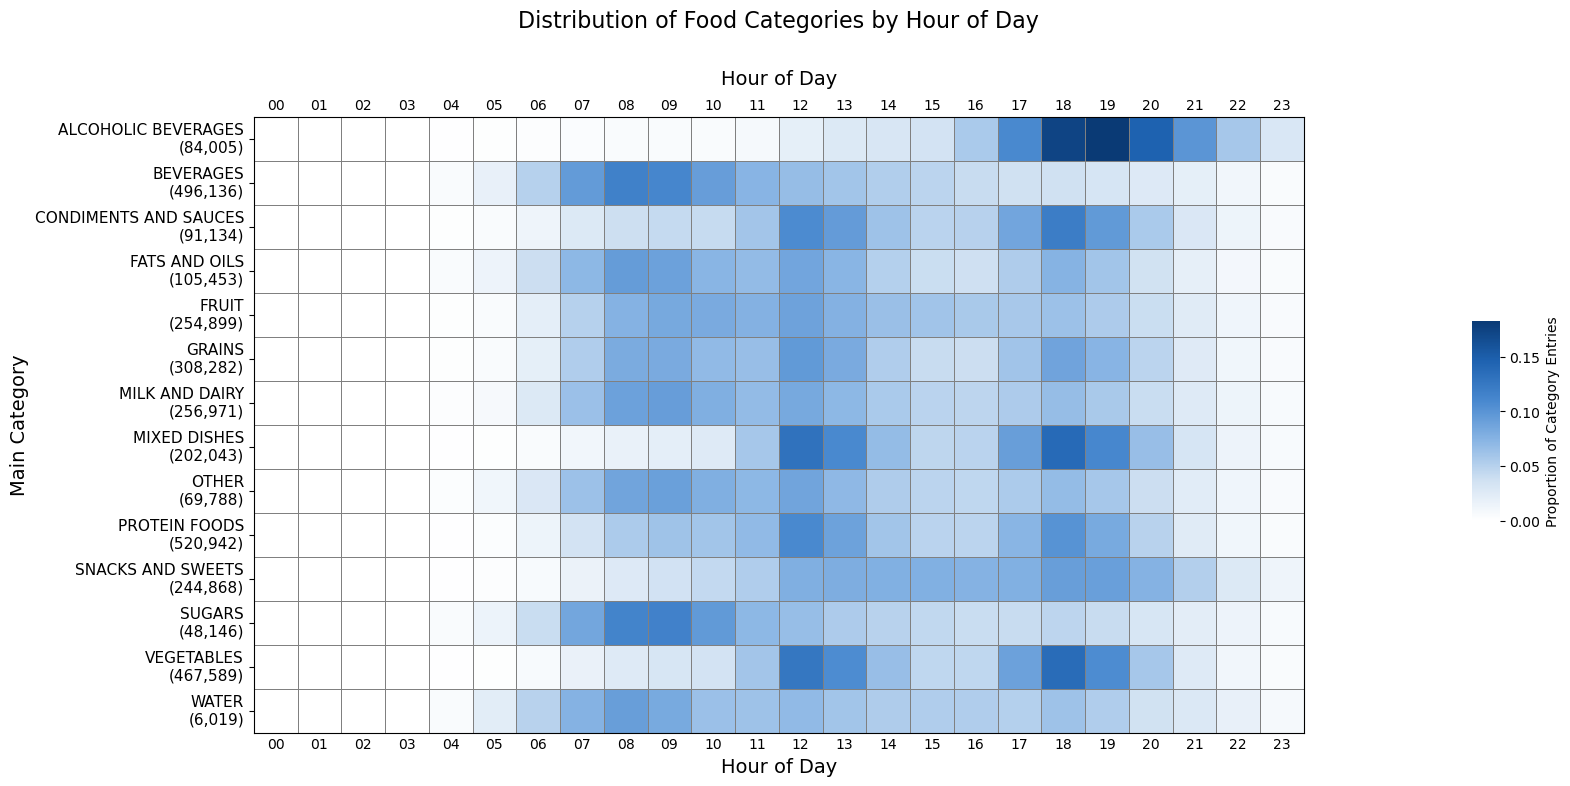

main_category,ALCOHOLIC BEVERAGES,BEVERAGES,CONDIMENTS AND SAUCES,FATS AND OILS,FRUIT,GRAINS,MILK AND DAIRY,MIXED DISHES,OTHER,PROTEIN FOODS,SNACKS AND SWEETS,SUGARS,VEGETABLES,WATER
hour,,,,,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.001202,0.005218,0.001525,0.004495,0.001695,0.001765,0.002175,0.000975,0.003468,0.001313,0.001335,0.004507,0.000828,0.005316


main_category
ALCOHOLIC BEVERAGES       84005
BEVERAGES                496136
CONDIMENTS AND SAUCES     91134
FATS AND OILS            105453
FRUIT                    254899
GRAINS                   308282
MILK AND DAIRY           256971
MIXED DISHES             202043
OTHER                     69788
PROTEIN FOODS            520942
SNACKS AND SWEETS        244868
SUGARS                    48146
VEGETABLES               467589
WATER                      6019
dtype: int64

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Assume user_food_df is ALREADY LOADED and correct.

def plot_time_heatmap(df):
    """Create a heatmap showing food category distribution by hour of day"""
    # --- NO CHANGES to imports or initial data processing ---
    # Extract hour from time column
    if 'hour' not in df.columns:
        # Use .loc to avoid potential SettingWithCopyWarning
        df = df.copy()
        df.loc[:, 'hour'] = df['time'].astype(int)
    else:
        # Ensure hour is integer even if already present
        df = df.copy()
        df.loc[:, 'hour'] = df['hour'].astype(int)

    # Count entries by hour and main category
    hourly_counts = df.groupby(['hour', 'main_category']).size().unstack(fill_value=0)

    # --- Ensure all hours 0-23 are represented BEFORE normalization ---
    # (This prevents errors if some hours have zero entries across all categories)
    all_hours = pd.Index(range(24), name='hour')
    hourly_counts = hourly_counts.reindex(index=all_hours, fill_value=0)
    # ---

    # Calculate total counts per category for labels
    category_totals = hourly_counts.sum(axis=0)

    # Normalize each category to show proportion rather than absolute count
    # (Slightly more robust way to handle potential division by zero)
    total_counts_for_norm = hourly_counts.sum(axis=0)
    hourly_proportions = hourly_counts.divide(total_counts_for_norm.replace(0, np.nan), axis=1).fillna(0)


    # --- NO CHANGES to Figure, Axes, Colorbar setup ---
    fig, ax = plt.subplots(figsize=(14, 8))
    cbar_ax = fig.add_axes([1.02, 0.375, 0.02, 0.25])

    # --- NO CHANGES to Y-labels or Colormap ---
    categories = hourly_proportions.columns.tolist() # Get categories after potential reindex
    custom_labels = [f"{cat}\n({category_totals.get(cat, 0):,})" for cat in categories] # Use .get() for safety

    colors = ["white", "#d0e1f2", "#89b5e4", "#4888cf", "#1e62b0", "#0a3a75"]
    custom_cmap = LinearSegmentedColormap.from_list("custom_blue", colors)

    # --- NO CHANGES to Heatmap Plotting Call ---
    sns.heatmap(
        hourly_proportions.T,
        cmap=custom_cmap,
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={'label': 'Proportion of Category Entries'},
        ax=ax,
        cbar_ax=cbar_ax
    )

    # Set the custom y-tick labels (Set rotation=0 for horizontal)
    ax.set_yticklabels(custom_labels, fontsize=11, rotation=0)

    # === X-Axis Formatting CHANGES START ===
    # Define tick locations and the desired "HH:00" labels
    tick_locations = np.arange(0.5, 24.5)
    hour_labels_formatted = [f"{h:02d}" for h in range(0, 24)]

    # Apply formatted labels and remove ticks for the BOTTOM axis
    ax.set_xticks(tick_locations)
    ax.set_xticklabels(hour_labels_formatted, fontsize=10) # USE FORMATTED LABELS
    ax.tick_params(axis='x', length=0)                   # REMOVE TICKS

    # Create a secondary x-axis at the top (NO CHANGE TO THIS LINE)
    ax2 = ax.twiny()

    # Make sure the top axis aligns with the bottom axis (NO CHANGE TO THIS LINE)
    ax2.set_xlim(ax.get_xlim())

    # Apply formatted labels and remove ticks for the TOP axis
    ax2.set_xticks(tick_locations)
    ax2.set_xticklabels(hour_labels_formatted, fontsize=10) # USE FORMATTED LABELS
    ax2.tick_params(axis='x', length=0)                  # REMOVE TICKS
    # === X-Axis Formatting CHANGES END ===

    # --- NO CHANGES to Title, Main Labels, Colorbar ticks ---
    # (Adjusted title padding slightly for top labels)
    plt.title('Distribution of Food Categories by Hour of Day', fontsize=16, pad=30)
    ax.set_xlabel('Hour of Day', fontsize=14)
    # Optionally add label to top axis too for clarity, adjust padding
    ax2.set_xlabel('Hour of Day', fontsize=14, labelpad=10)
    ax.set_ylabel('Main Category', fontsize=14)
    cbar_ax.tick_params(labelsize=10)

    # Adjust layout (Adjusted right margin slightly for cbar placement)
    plt.subplots_adjust(left=0.15, right=0.90) # Tweaked right margin

    plt.show()

    return hourly_proportions, category_totals

# === Function Call (EXACTLY AS PROVIDED BY USER) ===
# ASSUMES user_food_df IS ALREADY LOADED AND READY
hourly_proportions, category_totals = plot_time_heatmap(user_food_df)
display(hourly_proportions.head())
display(category_totals)

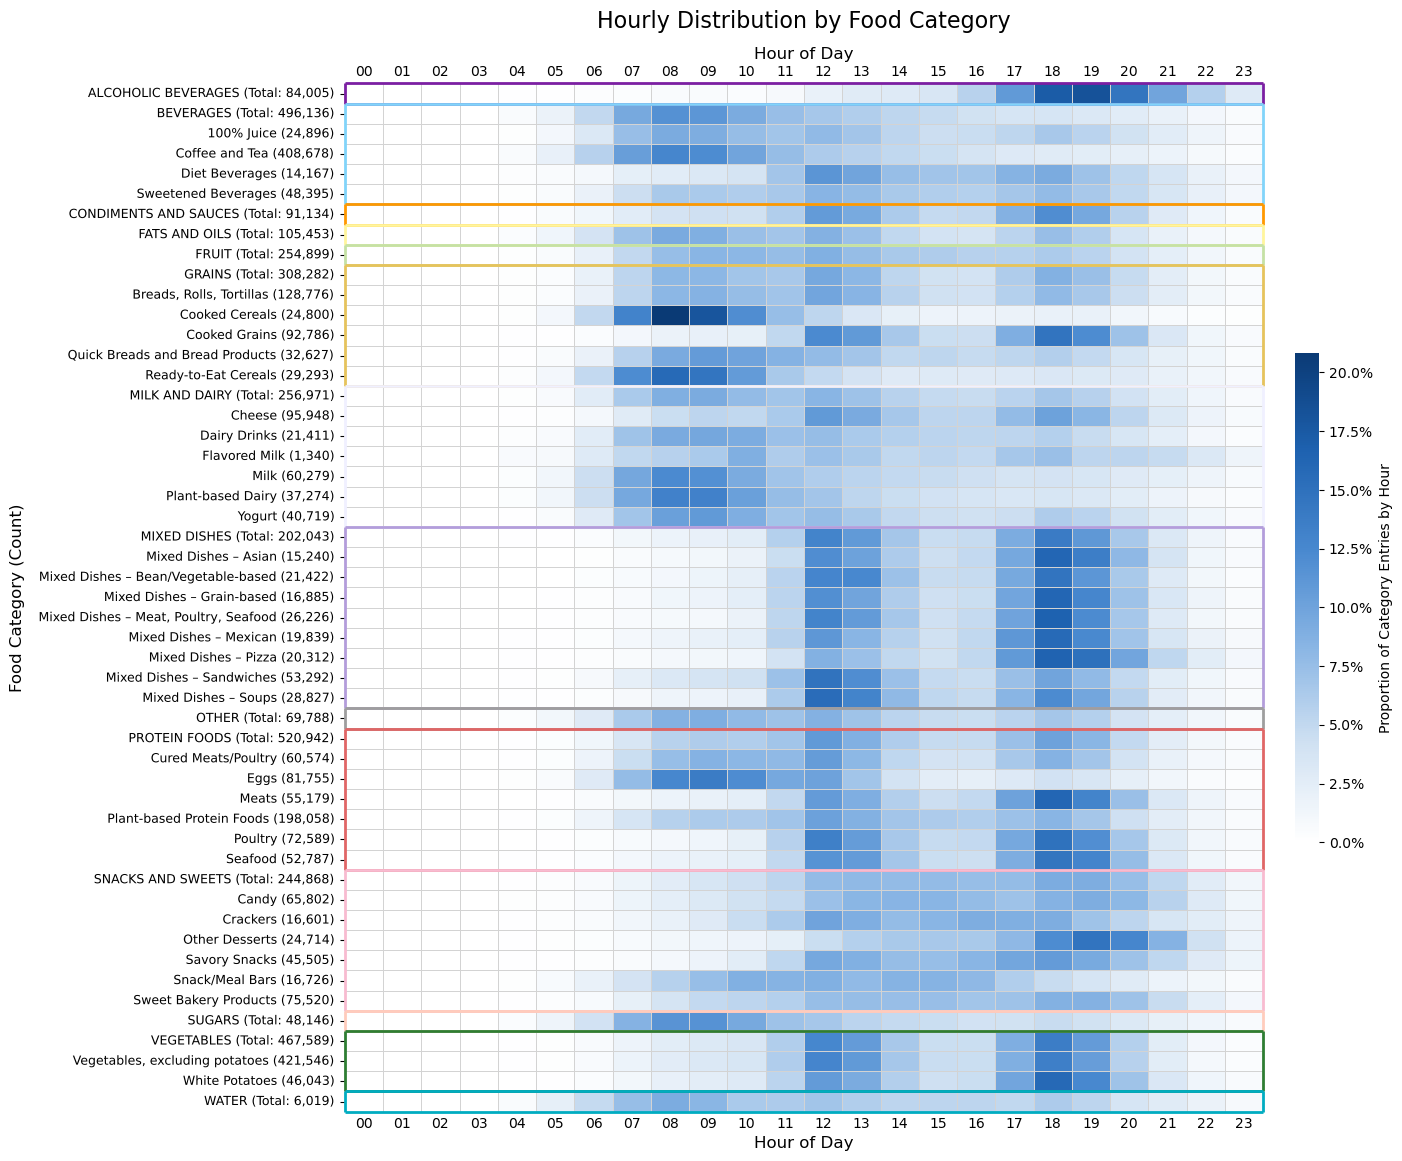

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from collections import Counter # Import Counter

# Assume user_food_df is ALREADY LOADED and correct.
# Assume custom_colors dictionary is defined as provided by the user.

def plot_grouped_heatmap_optimized(df, category_colors):
    """
    Create a heatmap with rows grouped by main category, aggregate rows,
    and colored line borders per main category group drawn on top, with
    axis spines removed. Secondary category rows are omitted if only one
    exists for a main category. Row height is reduced.
    Y-axis labels are black and normal weight.
    """
    df_proc = df.copy()

    # --- Data Preparation ---
    if 'hour' not in df_proc.columns:
        df_proc['hour'] = df_proc['time'].astype(int)
    else:
        df_proc['hour'] = df_proc['hour'].astype(int)

    valid_secondary_df = df_proc.dropna(subset=['secondary_category', 'main_category'])
    valid_secondary_df = valid_secondary_df[valid_secondary_df['secondary_category'] != '']

    secondary_to_main_map = valid_secondary_df.drop_duplicates(
        subset=['secondary_category']
    ).set_index('secondary_category')['main_category'].to_dict()
    default_main_cat = 'UNKNOWN'
    default_color = '#9E9E9E'

    # Calculate Proportions (Secondary and Main)
    sec_hourly_counts = valid_secondary_df.groupby(['hour', 'secondary_category']).size().unstack(fill_value=0)
    all_hours = pd.Index(range(24), name='hour')
    sec_hourly_counts = sec_hourly_counts.reindex(index=all_hours, fill_value=0)
    sec_category_totals = sec_hourly_counts.sum(axis=0)
    valid_sec_categories = sec_category_totals[sec_category_totals > 0].index
    sec_hourly_counts = sec_hourly_counts[valid_sec_categories]
    sec_category_totals = sec_category_totals[valid_sec_categories]
    sec_hourly_proportions = sec_hourly_counts.divide(sec_category_totals.replace(0, np.nan), axis=1).fillna(0)

    main_hourly_counts = valid_secondary_df.groupby(['hour', 'main_category']).size().unstack(fill_value=0)
    main_hourly_counts = main_hourly_counts.reindex(index=all_hours, fill_value=0)
    main_category_totals = main_hourly_counts.sum(axis=0)
    valid_main_categories = main_category_totals[main_category_totals > 0].index
    main_hourly_counts = main_hourly_counts[valid_main_categories]
    main_category_totals = main_category_totals[valid_main_categories]
    main_hourly_proportions = main_hourly_counts.divide(main_category_totals.replace(0, np.nan), axis=1).fillna(0)

    # --- Sorting and Filtering ---
    sort_tuples = []
    main_cat_secondary_counts = Counter() # Count secondaries per main
    for sec_cat in valid_sec_categories:
        main_cat = secondary_to_main_map.get(sec_cat)
        if main_cat in valid_main_categories:
             sort_tuples.append((main_cat, sec_cat))
             main_cat_secondary_counts[main_cat] += 1 # Increment count

    sorted_tuples = sorted(sort_tuples)

    # --- Build Combined Data (Skip single secondaries) ---
    combined_data_rows = []
    combined_index = []
    final_labels = []
    category_spans = {}
    current_main_category = None
    row_counter = 0
    current_span_start = 0

    for main_cat, sec_cat in sorted_tuples:
        # Start New Group
        if main_cat != current_main_category:
            if current_main_category is not None:
                # Store span end for previous category before starting new one
                category_spans[current_main_category] = (current_span_start, row_counter)
            current_span_start = row_counter # Reset start for the new category

            # Add Main Category Row
            if main_cat in main_hourly_proportions.columns:
                 combined_data_rows.append(main_hourly_proportions[main_cat].tolist())
                 combined_index.append(main_cat)
                 final_labels.append(f"{main_cat} (Total: {main_category_totals.get(main_cat, 0):,})")
                 current_main_category = main_cat
                 row_counter += 1

        # Add Secondary Category Row ONLY if its main category has more than one secondary
        if main_cat_secondary_counts[main_cat] > 1:
            if sec_cat in sec_hourly_proportions.columns:
                combined_data_rows.append(sec_hourly_proportions[sec_cat].tolist())
                combined_index.append(sec_cat)
                # Add secondary label with indent for visual hierarchy
                final_labels.append(f"  {sec_cat} ({sec_category_totals.get(sec_cat, 0):,})")
                row_counter += 1

    # Finalize the last span after loop finishes
    if current_main_category is not None:
        category_spans[current_main_category] = (current_span_start, row_counter)

    if not combined_data_rows:
        print("No data to plot after processing.")
        return None, None

    combined_hourly_proportions = pd.DataFrame(combined_data_rows, index=combined_index, columns=all_hours)
    num_rows_plot = combined_hourly_proportions.shape[0]
    num_cols_plot = combined_hourly_proportions.shape[1]

    # --- Plotting Setup ---
    # Adjusted row height factor
    row_height_factor = 0.24 # Reduced from 0.28
    fig_height = max(8, num_rows_plot * row_height_factor) # Set a minimum height
    fig, ax = plt.subplots(figsize=(16, fig_height))
    cbar_ax = fig.add_axes([0.93, 0.3, 0.015, 0.4]) # Adjust cbar position if needed


    colors = ["white", "#d0e1f2", "#89b5e4", "#4888cf", "#1e62b0", "#0a3a75"]
    custom_cmap = LinearSegmentedColormap.from_list("custom_blue", colors)

    # # Colormap
    # colors = ["#f7fbff", "#deebf7", "#c6dbef", "#9ecae1", "#6baed6", "#3182bd", "#08519c"]
    # custom_cmap = LinearSegmentedColormap.from_list("custom_blue", colors)

    # --- Heatmap Plotting ---
    heatmap_zorder = 1
    sns.heatmap(
        combined_hourly_proportions,
        cmap=custom_cmap,
        linewidths=0.5,
        linecolor='lightgray',
        cbar_kws={'label': 'Proportion of Category Entries by Hour'},
        ax=ax,
        cbar_ax=cbar_ax,
        fmt=".1%",
        zorder=heatmap_zorder
    )
    # Lower zorder for internal grid lines if possible
    try:
        for collection in ax.collections:
            if isinstance(collection, plt.collections.LineCollection):
                 collection.set_zorder(heatmap_zorder - 1)
            else:
                 collection.set_zorder(heatmap_zorder)
    except Exception: pass # Ignore if it fails

    # --- Draw Colored Borders using Lines ---
    border_linewidth = 2.0
    border_zorder = heatmap_zorder + 5

    # Sort spans again based on the final row indices stored
    sorted_spans_final = sorted(category_spans.items(), key=lambda item: item[1][0])

    for main_cat, (start_row, end_row) in sorted_spans_final:
        # Check if the span is valid (end > start) after potential row removals
        if end_row <= start_row:
            continue # Skip drawing if span is empty or invalid

        border_color = category_colors.get(main_cat, default_color)
        # Horizontal lines
        ax.plot([0, num_cols_plot], [start_row, start_row], color=border_color, linewidth=border_linewidth, zorder=border_zorder, solid_capstyle='butt', clip_on=False) # Top
        ax.plot([0, num_cols_plot], [end_row, end_row], color=border_color, linewidth=border_linewidth, zorder=border_zorder, solid_capstyle='butt', clip_on=False) # Bottom
        # Vertical lines
        ax.plot([0, 0], [start_row, end_row], color=border_color, linewidth=border_linewidth, zorder=border_zorder, solid_capstyle='butt', clip_on=False) # Left
        ax.plot([num_cols_plot, num_cols_plot], [start_row, end_row], color=border_color, linewidth=border_linewidth, zorder=border_zorder, solid_capstyle='butt', clip_on=False) # Right

    # --- Y-Axis Label Formatting ---
    ax.set_yticks(np.arange(num_rows_plot) + 0.5)
    # Use 'final_labels' which includes the indent for secondary categories
    ax.set_yticklabels(final_labels, fontsize=9, rotation=0, color='black', weight='normal', va='center') # Reduced font size slightly
    label_zorder = border_zorder + 1
    for label in ax.get_yticklabels():
        label.set_path_effects([pe.Normal()])
        label.set_zorder(label_zorder)

    # --- X-Axis Formatting (Dual Axis) ---
    hour_labels_formatted = [f"{h:02d}" for h in range(num_cols_plot)]
    ax.set_xticks(np.arange(num_cols_plot) + 0.5)
    ax.set_xticklabels(hour_labels_formatted, fontsize=10)
    ax.tick_params(axis='x', which='both', length=0)

    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(np.arange(num_cols_plot) + 0.5)
    ax2.set_xticklabels(hour_labels_formatted, fontsize=10)
    ax2.tick_params(axis='x', which='both', length=0)

    # --- Final Touches ---
    ax.set_title('Hourly Distribution by Food Category', fontsize=16, pad=40)
    ax.set_xlabel('Hour of Day', fontsize=12)
    ax2.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Food Category (Count)', fontsize=12)
    cbar_ax.tick_params(labelsize=10)
    cbar_ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

    # Remove the default axes spines (plot border)
    for spine_loc in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine_loc].set_visible(False)
        ax2.spines[spine_loc].set_visible(False)

    # Adjust layout
    # Recalculate max label length based on final labels
    max_label_len = max(len(lbl) for lbl in final_labels) if final_labels else 0
    left_margin = max(0.25, min(0.5, max_label_len * 0.007)) # Adjusted factor slightly for smaller font
    plt.subplots_adjust(left=left_margin, right=0.91, top=0.92, bottom=0.08)

    # Set Axis limits AFTER removing spines and drawing borders
    ax.set_ylim(num_rows_plot, 0)
    ax.set_xlim(0, num_cols_plot)
    ax2.set_ylim(ax.get_ylim())

    plt.show()

    return combined_hourly_proportions, main_category_totals, sec_category_totals

# --- Function Call ---
# Ensure custom_colors is defined as in the problem description
# Ensure user_food_df is loaded
(combined_proportions_opt,
 main_totals_opt,
 sec_totals_opt) = plot_grouped_heatmap_optimized(user_food_df, custom_colors)

# Optional: Display the results
# if combined_proportions_opt is not None:
#    print("Combined Hourly Proportions (Optimized):")
#    display(combined_proportions_opt.head())
#    print("\nMain Category Totals:")
#    display(main_totals_opt)
#    print("\nSecondary Category Totals (Original before filtering):")
#    display(sec_totals_opt) # Note: sec_totals still holds original totals

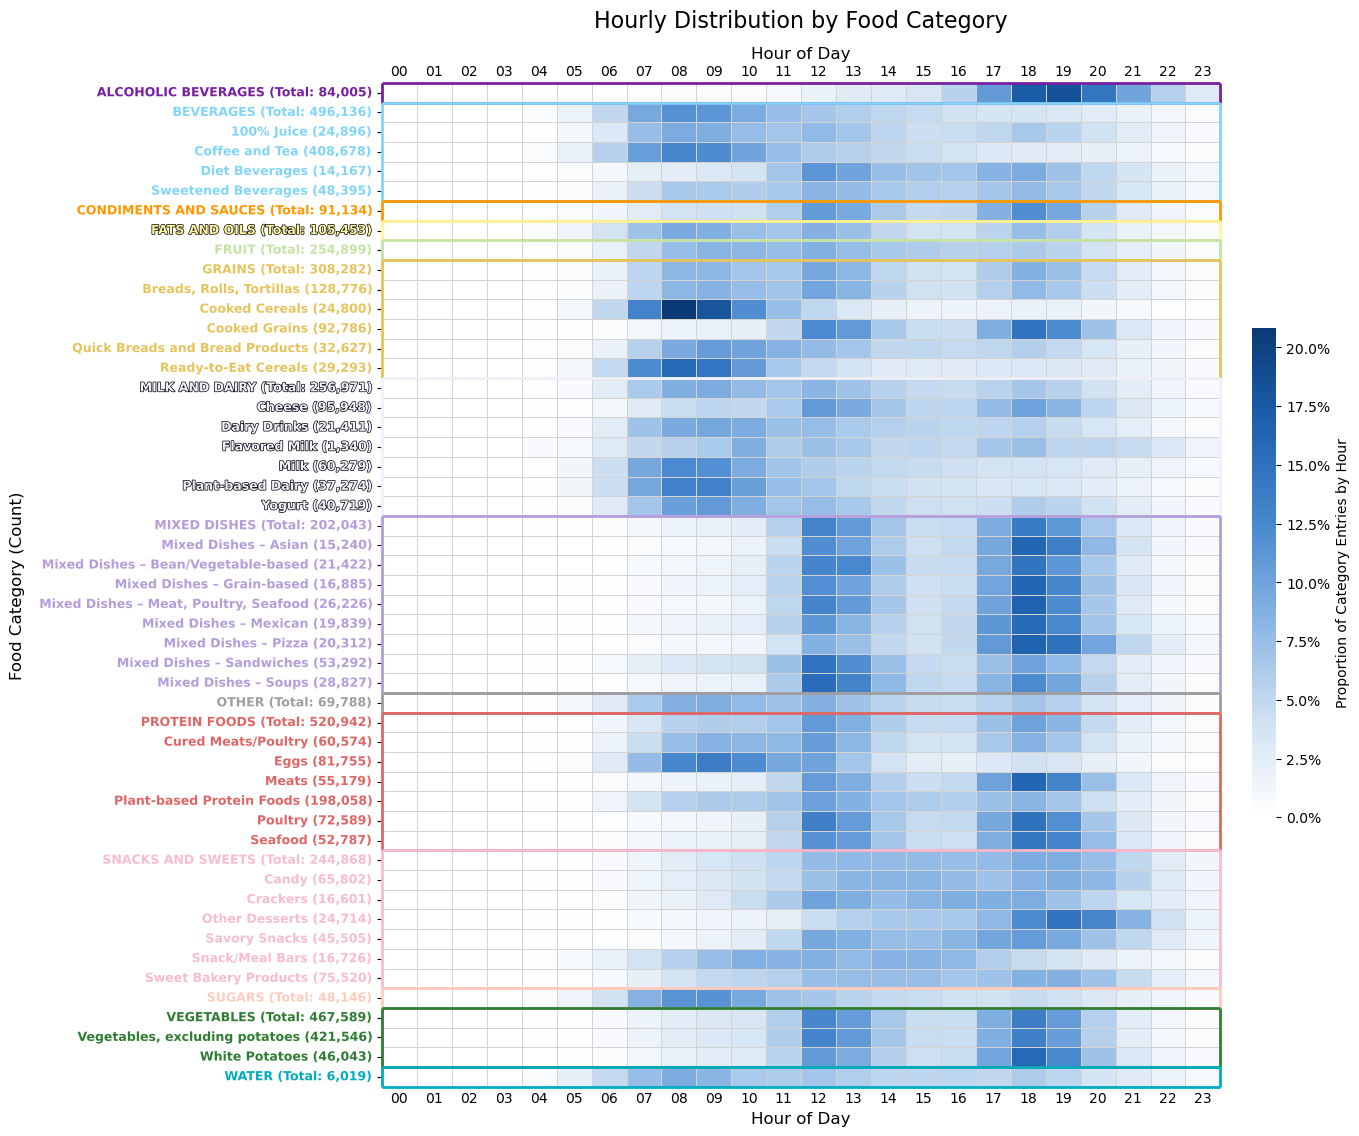

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, to_rgb # Import to_rgb
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from collections import Counter

# Assume user_food_df is ALREADY LOADED and correct.
# Assume custom_colors dictionary is defined as provided by the user.

def calculate_luminance(color):
    """Calculates the relative luminance of a color.

    Args:
        color: A color string (e.g., hex '#RRGGBB') or RGB tuple (0-1).

    Returns:
        Relative luminance (0.0 to 1.0). Returns 0 for invalid colors.
    """
    try:
        rgb = to_rgb(color) # Convert hex/name to RGB tuple (0-1)
        # Formula for relative luminance (WCAG)
        # Adjust components for non-linear perception if needed, but this is standard
        r, g, b = [x / 1.0 for x in rgb] # Ensure float division if needed
        # Gamma correction - approximate sRGB correction
        r = r / 12.92 if r <= 0.03928 else ((r + 0.055) / 1.055) ** 2.4
        g = g / 12.92 if g <= 0.03928 else ((g + 0.055) / 1.055) ** 2.4
        b = b / 12.92 if b <= 0.03928 else ((b + 0.055) / 1.055) ** 2.4
        luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
        return luminance
    except ValueError:
        print(f"Warning: Could not parse color '{color}' for luminance calculation.")
        return 0.0 # Return 0 (dark) for unparseable colors

def plot_grouped_heatmap_optimized(df, category_colors, luminance_threshold=0.6):
    """
    Create a heatmap with rows grouped by main category, aggregate rows,
    and colored line borders per main category group drawn on top, with
    axis spines removed. Secondary category rows are omitted if only one
    exists for a main category. Row height is reduced.
    Y-axis labels are bold, colored by their corresponding main category.
    A black stroke is applied ONLY if the label color's luminance is above
    the threshold (i.e., for lighter colors).
    """
    df_proc = df.copy()

    # --- Data Preparation ---
    if 'hour' not in df_proc.columns:
        df_proc['hour'] = df_proc['time'].astype(int)
    else:
        df_proc['hour'] = df_proc['hour'].astype(int)

    valid_secondary_df = df_proc.dropna(subset=['secondary_category', 'main_category'])
    valid_secondary_df = valid_secondary_df[valid_secondary_df['secondary_category'] != '']

    secondary_to_main_map = valid_secondary_df.drop_duplicates(
        subset=['secondary_category']
    ).set_index('secondary_category')['main_category'].to_dict()
    default_main_cat = 'UNKNOWN'
    default_color = '#9E9E9E'

    # Calculate Proportions (Secondary and Main)
    sec_hourly_counts = valid_secondary_df.groupby(['hour', 'secondary_category']).size().unstack(fill_value=0)
    all_hours = pd.Index(range(24), name='hour')
    sec_hourly_counts = sec_hourly_counts.reindex(index=all_hours, fill_value=0)
    sec_category_totals = sec_hourly_counts.sum(axis=0)
    valid_sec_categories = sec_category_totals[sec_category_totals > 0].index
    sec_hourly_counts = sec_hourly_counts[valid_sec_categories]
    sec_hourly_proportions = sec_hourly_counts.divide(sec_category_totals[valid_sec_categories].replace(0, np.nan), axis=1).fillna(0)

    main_hourly_counts = valid_secondary_df.groupby(['hour', 'main_category']).size().unstack(fill_value=0)
    main_hourly_counts = main_hourly_counts.reindex(index=all_hours, fill_value=0)
    main_category_totals = main_hourly_counts.sum(axis=0)
    valid_main_categories = main_category_totals[main_category_totals > 0].index
    main_hourly_counts = main_hourly_counts[valid_main_categories]
    main_hourly_proportions = main_hourly_counts.divide(main_category_totals[valid_main_categories].replace(0, np.nan), axis=1).fillna(0)

    # --- Sorting and Filtering ---
    sort_tuples = []
    main_cat_secondary_counts = Counter()
    for sec_cat in valid_sec_categories:
        main_cat = secondary_to_main_map.get(sec_cat)
        if main_cat in valid_main_categories:
             sort_tuples.append((main_cat, sec_cat))
             main_cat_secondary_counts[main_cat] += 1

    sorted_tuples = sorted(sort_tuples)

    # --- Build Combined Data ---
    combined_data_rows = []
    combined_index = []
    row_main_category_map = {}
    final_labels = []
    category_spans = {}
    current_main_category = None
    row_counter = 0
    current_span_start = 0

    for main_cat, sec_cat in sorted_tuples:
        if main_cat != current_main_category:
            if current_main_category is not None: category_spans[current_main_category] = (current_span_start, row_counter)
            current_span_start = row_counter
            if main_cat in main_hourly_proportions.columns:
                 combined_data_rows.append(main_hourly_proportions[main_cat].tolist())
                 combined_index.append(main_cat)
                 final_labels.append(f"{main_cat} (Total: {main_category_totals.get(main_cat, 0):,})")
                 row_main_category_map[row_counter] = main_cat
                 current_main_category = main_cat
                 row_counter += 1

        if main_cat_secondary_counts[main_cat] > 1 and sec_cat in sec_hourly_proportions.columns:
            combined_data_rows.append(sec_hourly_proportions[sec_cat].tolist())
            combined_index.append(sec_cat)
            final_labels.append(f"  {sec_cat} ({sec_category_totals.get(sec_cat, 0):,})")
            row_main_category_map[row_counter] = main_cat # Map to parent main category
            row_counter += 1

    if current_main_category is not None: category_spans[current_main_category] = (current_span_start, row_counter)

    if not combined_data_rows:
        print("No data to plot after processing.")
        return None, None, None

    combined_hourly_proportions = pd.DataFrame(combined_data_rows, index=combined_index, columns=all_hours)
    num_rows_plot = combined_hourly_proportions.shape[0]
    num_cols_plot = combined_hourly_proportions.shape[1]

    # --- Plotting Setup ---
    row_height_factor = 0.24
    fig_height = max(8, num_rows_plot * row_height_factor)
    fig, ax = plt.subplots(figsize=(16, fig_height))
    cbar_ax = fig.add_axes([0.93, 0.3, 0.015, 0.4])
    colors = ["white", "#d0e1f2", "#89b5e4", "#4888cf", "#1e62b0", "#0a3a75"]
    custom_cmap = LinearSegmentedColormap.from_list("custom_blue", colors)

    # --- Heatmap Plotting ---
    heatmap_zorder = 1
    sns.heatmap(
        combined_hourly_proportions, cmap=custom_cmap, linewidths=0.5, linecolor='lightgray',
        cbar_kws={'label': 'Proportion of Category Entries by Hour'}, ax=ax, cbar_ax=cbar_ax,
        fmt=".1%", zorder=heatmap_zorder, annot=False
    )
    try:
        for child in ax.get_children():
            if isinstance(child, plt.collections.LineCollection): child.set_zorder(heatmap_zorder - 1)
            elif hasattr(child, 'set_zorder'): child.set_zorder(heatmap_zorder)
    except Exception: pass

    # --- Draw Colored Borders ---
    border_linewidth = 2.0
    border_zorder = heatmap_zorder + 5
    sorted_spans_final = sorted(category_spans.items(), key=lambda item: item[1][0])
    for main_cat, (start_row, end_row) in sorted_spans_final:
        if end_row <= start_row: continue
        border_color = category_colors.get(main_cat, default_color)
        ax.plot([0, num_cols_plot], [start_row, start_row], color=border_color, lw=border_linewidth, zorder=border_zorder, solid_capstyle='butt', clip_on=False)
        ax.plot([0, num_cols_plot], [end_row, end_row], color=border_color, lw=border_linewidth, zorder=border_zorder, solid_capstyle='butt', clip_on=False)
        ax.plot([0, 0], [start_row, end_row], color=border_color, lw=border_linewidth, zorder=border_zorder, solid_capstyle='butt', clip_on=False)
        ax.plot([num_cols_plot, num_cols_plot], [start_row, end_row], color=border_color, lw=border_linewidth, zorder=border_zorder, solid_capstyle='butt', clip_on=False)

    # --- Y-Axis Label Formatting with Conditional Stroke ---
    ax.set_yticks(np.arange(num_rows_plot) + 0.5)
    ax.set_yticklabels(final_labels, fontsize=9, rotation=0, va='center')
    label_zorder = border_zorder + 1

    for i, label in enumerate(ax.get_yticklabels()):
        associated_main_cat = row_main_category_map.get(i)
        label_color = category_colors.get(associated_main_cat, default_color) if associated_main_cat else default_color

        label.set_color(label_color)
        label.set_weight("heavy")
        label.set_zorder(label_zorder)

        # Calculate luminance and apply stroke conditionally
        luminance = calculate_luminance(label_color)
        if luminance > luminance_threshold:
            # Apply stroke for light colors
            label.set_path_effects([pe.withStroke(linewidth=1.0, foreground='black')])
        else:
            # No stroke for dark colors (ensure no lingering effects)
            label.set_path_effects([pe.Normal()])

    # --- X-Axis Formatting (Dual Axis) ---
    hour_labels_formatted = [f"{h:02d}" for h in range(num_cols_plot)]
    ax.set_xticks(np.arange(num_cols_plot) + 0.5); ax.set_xticklabels(hour_labels_formatted, fontsize=10)
    ax.tick_params(axis='x', which='both', length=0)
    ax2 = ax.twiny(); ax2.set_xlim(ax.get_xlim()); ax2.set_xticks(np.arange(num_cols_plot) + 0.5)
    ax2.set_xticklabels(hour_labels_formatted, fontsize=10); ax2.tick_params(axis='x', which='both', length=0)

    # --- Final Touches ---
    ax.set_title('Hourly Distribution by Food Category', fontsize=16, pad=40)
    ax.set_xlabel('Hour of Day', fontsize=12); ax2.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Food Category (Count)', fontsize=12)
    cbar_ax.tick_params(labelsize=10); cbar_ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
    for spine_loc in ['top', 'right', 'bottom', 'left']: ax.spines[spine_loc].set_visible(False); ax2.spines[spine_loc].set_visible(False)
    max_label_len = max(len(lbl) for lbl in final_labels) if final_labels else 0
    left_margin = max(0.20, min(0.4, max_label_len * 0.007 + 0.05))
    plt.subplots_adjust(left=left_margin, right=0.91, top=0.90, bottom=0.08)
    ax.set_ylim(num_rows_plot, 0); ax.set_xlim(0, num_cols_plot); ax2.set_ylim(ax.get_ylim())

    plt.show()
    return combined_hourly_proportions, main_category_totals, sec_category_totals

# --- Function Call Example ---
# Ensure user_food_df and custom_colors are loaded and defined
# You can adjust the luminance_threshold (0.0 to 1.0)
# Values > 0.5-0.6 are generally considered "light"
(combined_proportions_opt,
 main_totals_opt,
 sec_totals_opt) = plot_grouped_heatmap_optimized(user_food_df, custom_colors, luminance_threshold=0.7)

# Optional: Display results
# if combined_proportions_opt is not None:
#     print("Combined Hourly Proportions (Optimized):"); display(combined_proportions_opt.head())
#     print("\nMain Category Totals:"); display(main_totals_opt)
#     print("\nSecondary Category Totals (Valid ones used in calculation):"); display(sec_totals_opt)

In [96]:
user_food_df.to_csv("user_food_usda_df.csv")

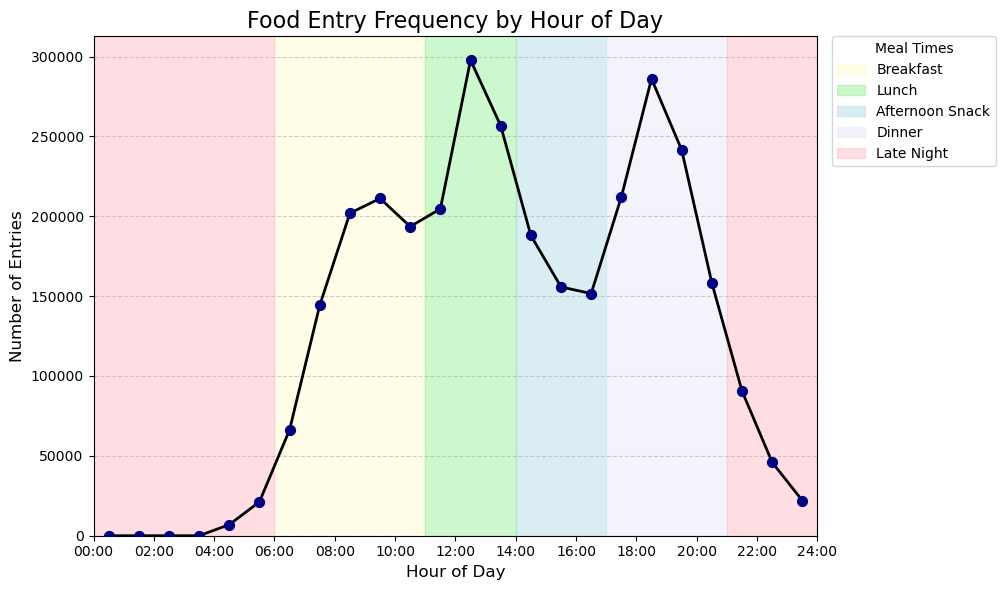

,Count
Hour,
0,0
1,0
2,0
3,0
4,"6,924"
5,"21,191"
6,"66,310"
7,"144,275"
8,"201,899"


,Total Count
Meal Time,
Breakfast,"817,187"
Lunch,"759,074"
Afternoon Snack,"495,321"
Dinner,"897,969"
Late Night,"186,724"


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
# Import display function for rendering styled tables
from IPython.display import display, HTML

# --- Previous plot_hourly_consumption function (assuming it's defined as in the last step) ---
# ... (Keep the plot_hourly_consumption function definition here) ...
def plot_hourly_consumption(df):
    """
    Plot total food entries by hour of day with more visible meal time highlights
    shown in a legend. (Copied from previous correct version)
    """
    # --- Data Preparation ---
    if 'hour' not in df.columns:
        df = df.copy()
        df.loc[:, 'hour'] = df['time'].astype(int)
    else:
        df = df.copy()
        df.loc[:, 'hour'] = df['hour'].astype(int)

    total_by_hour = df.groupby('hour').size()
    all_hours = range(24)
    all_hour_counts = total_by_hour.reindex(all_hours, fill_value=0)

    # --- Plotting Setup ---
    plt.figure(figsize=(12, 6))
    ax = plt.gca()

    # Plot the hourly counts
    bin_centers = np.array(all_hour_counts.index) + 0.5
    ax.plot(bin_centers, all_hour_counts.values, '-', linewidth=2, label='Hourly Entries', color='black')
    ax.scatter(bin_centers, all_hour_counts.values, s=50, color='navy', zorder=3)

    # --- Meal Time Shading and Legend Preparation ---
    meal_times = [
        ('Breakfast', 6, 11),
        ('Lunch', 11, 14),
        ('Afternoon Snack', 14, 17),
        ('Dinner', 17, 21),
        ('Late Night', 21, 24),
        ('Late Night', 0, 6)
    ]
    colors = ['#FFFACD', '#90EE90', '#ADD8E6', '#E6E6FA', '#FFB6C1', '#FFB6C1']
    new_alpha = 0.45

    legend_patches = []
    seen_labels = set()

    for i, (meal, start, end) in enumerate(meal_times):
        ax.axvspan(start, end, alpha=new_alpha, color=colors[i], zorder=0)
        if meal not in seen_labels:
            patch = mpatches.Patch(color=colors[i], alpha=new_alpha, label=meal)
            legend_patches.append(patch)
            seen_labels.add(meal)

    # --- Axis Formatting and Labels ---
    ax.set_xticks(range(0, 25, 2))
    ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 25, 2)])
    ax.set_xlim(0, 24)
    ax.set_ylim(bottom=0)
    ax.set_title('Food Entry Frequency by Hour of Day', fontsize=16)
    ax.set_xlabel('Hour of Day', fontsize=12)
    ax.set_ylabel('Number of Entries', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6, axis='y')

    # --- Add the Legend ---
    ax.legend(handles=legend_patches, title="Meal Times",
              bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

    return all_hour_counts
# --- End of plot_hourly_consumption function ---


# --- NEW FUNCTION to display styled tables ---
def display_frequency_tables(hourly_counts_series):
    """
    Displays styled tables for hourly frequency and mealtime frequency.

    Args:
        hourly_counts_series (pd.Series): Series with hours (0-23) as index
                                           and counts as values.
    """
    if not isinstance(hourly_counts_series, pd.Series):
        print("Input must be a Pandas Series.")
        return
    if not hourly_counts_series.index.equals(pd.Index(range(24))):
         print("Warning: Input Series does not seem to have all hours 0-23 as index.")


    # --- 1. Prepare Hourly Table ---
    hourly_df = pd.DataFrame(hourly_counts_series)
    hourly_df.columns = ['Count']
    hourly_df.index.name = 'Hour'

    # Style the hourly table
    styled_hourly = hourly_df.style \
        .set_caption("Food Entry Frequency by Hour") \
        .format('{:,}') \
        .bar(color='#ADD8E6', vmin=0) \
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'th', 'props': [('text-align', 'center')]},
            {'selector': 'td', 'props': [('text-align', 'right')]}
        ])

    # --- 2. Prepare Mealtime Table ---
    # Define meal times (consistent with the plot)
    meal_times_def = [
        ('Breakfast', 6, 11),
        ('Lunch', 11, 14),
        ('Afternoon Snack', 14, 17),
        ('Dinner', 17, 21),
        ('Late Night', 21, 24),
        ('Late Night', 0, 6)
    ]

    # Create a mapping from hour to meal name
    hour_to_meal_map = pd.Series(index=range(24), dtype=str)
    for meal, start, end in meal_times_def:
        # Handle wrap-around for ranges like (21, 24) which means 21, 22, 23
        # and (0, 6) which means 0, 1, 2, 3, 4, 5
        # The logic below correctly maps hours within range(start, end)
        for hour in range(start, end):
             # Ensure we don't overwrite if an hour is somehow in multiple ranges
             # (though our definition avoids this except for the split Late Night)
             # This logic is simplified as groupby will handle the split 'Late Night' fine
             hour_to_meal_map[hour] = meal

    # Group the hourly counts by the meal mapping and sum
    meal_counts = hourly_counts_series.groupby(hour_to_meal_map).sum()

    # Ensure consistent order of meal times in the output table
    ordered_meal_names = []
    seen_meals_order = set()
    for meal, _, _ in meal_times_def:
        if meal not in seen_meals_order:
            ordered_meal_names.append(meal)
            seen_meals_order.add(meal)
    # Reindex to ensure all defined meals are present and in order
    meal_counts = meal_counts.reindex(ordered_meal_names, fill_value=0)


    # Create DataFrame for styling
    meal_df = pd.DataFrame(meal_counts)
    meal_df.columns = ['Total Count']
    meal_df.index.name = 'Meal Time'

    # Style the mealtime table
    styled_mealtime = meal_df.style \
        .set_caption("Total Food Entry Frequency by Meal Time") \
        .format('{:,}') \
        .bar(color='#90EE90', vmin=0) \
        .set_table_styles([
             {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('text-align', 'center')]},
             {'selector': 'th', 'props': [('text-align', 'left')]}, # Align meal names left
             {'selector': 'td', 'props': [('text-align', 'right')]}
        ])


    # --- 3. Display the Tables ---
    print("\n" + "="*40)
    display(styled_hourly)
    print("\n" + "="*40)
    display(styled_mealtime)
    print("="*40)


# --- Usage ---
# First, run the plot function (assuming user_food_df is loaded)
total_by_hour_result = plot_hourly_consumption(user_food_df)

# Now, display the styled tables using the result
display_frequency_tables(total_by_hour_result)

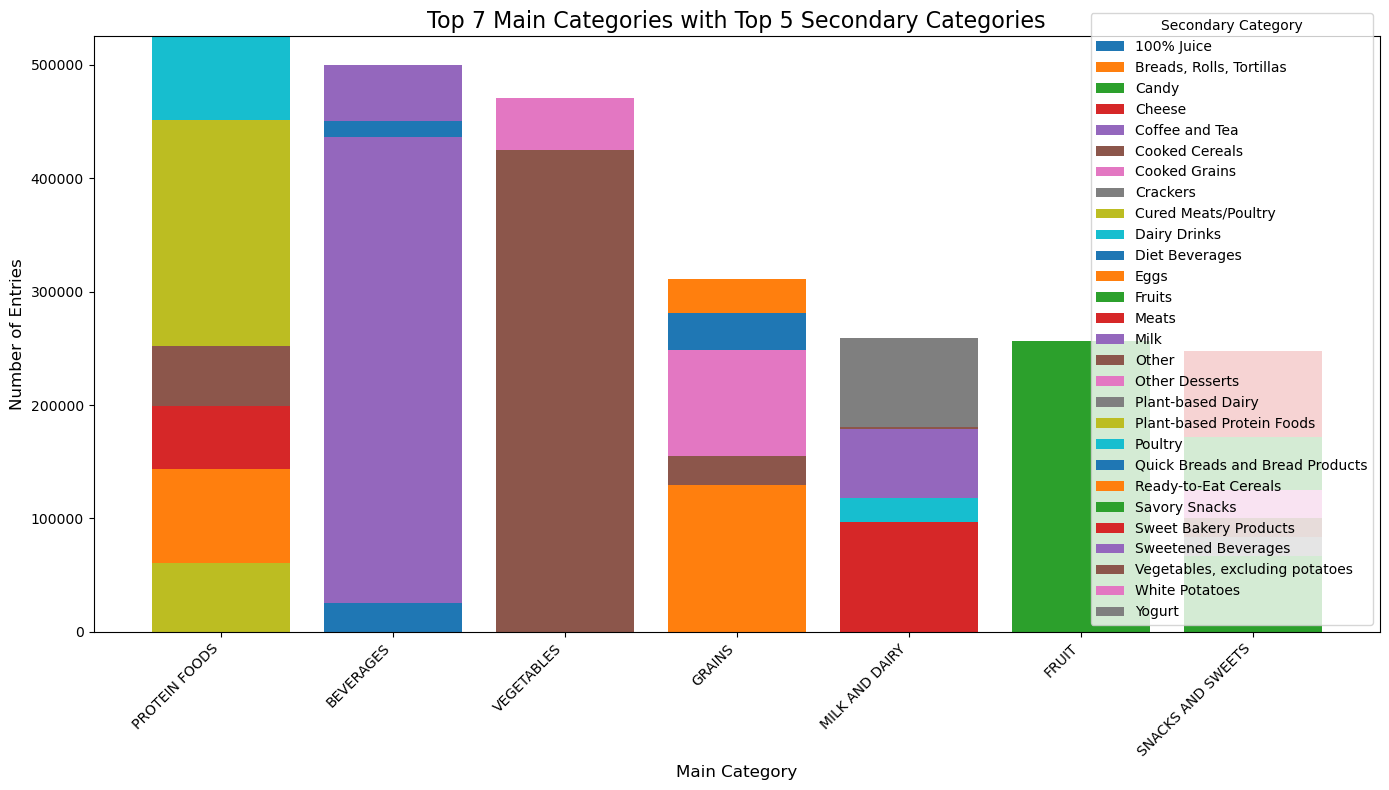

In [36]:
def plot_stacked_bars(df, top_n_main=7, top_n_secondary=5):
    """Create a stacked bar chart showing top secondary categories within main categories"""
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Get top main categories
    top_main = df['main_category'].value_counts().nlargest(top_n_main).index
    
    # Prepare data structure
    data = {}
    for main in top_main:
        # Get counts of secondary categories for this main category
        secondary_counts = df[df['main_category'] == main]['secondary_category'].value_counts()
        
        # Get top N secondary categories and sum the rest into 'Other'
        top_secondary = secondary_counts.nlargest(top_n_secondary)
        other_count = secondary_counts.sum() - top_secondary.sum()
        
        # Store in our data structure
        data[main] = top_secondary.to_dict()
        if other_count > 0:
            data[main]['Other'] = other_count
    
    # Prepare for plotting
    main_categories = list(data.keys())
    secondary_categories = set()
    for main, sec_dict in data.items():
        secondary_categories.update(sec_dict.keys())
    secondary_categories = sorted(secondary_categories)
    
    # Create a structured array for stacking
    stacked_data = []
    for sec in secondary_categories:
        stacked_data.append([data[main].get(sec, 0) for main in main_categories])
    
    # Create plot
    fig, ax = plt.subplots(figsize=(14, 8))
    
    bottom = np.zeros(len(main_categories))
    for i, sec_data in enumerate(stacked_data):
        if i < len(secondary_categories):
            sec = list(secondary_categories)[i]
            ax.bar(main_categories, sec_data, bottom=bottom, label=sec)
            bottom += sec_data
    
    ax.set_title(f'Top {top_n_main} Main Categories with Top {top_n_secondary} Secondary Categories', fontsize=16)
    ax.set_xlabel('Main Category', fontsize=12)
    ax.set_ylabel('Number of Entries', fontsize=12)
    ax.legend(title='Secondary Category')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    return data  # Return processed data for further analysis

# Create the stacked bar chart
stacked_data = plot_stacked_bars(user_food_df, top_n_main=7, top_n_secondary=5)

/var/folders/dv/lndb9rrs2kv2v5g8cyfyx0wr0000gn/T/ipykernel_75865/692828754.py:50: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



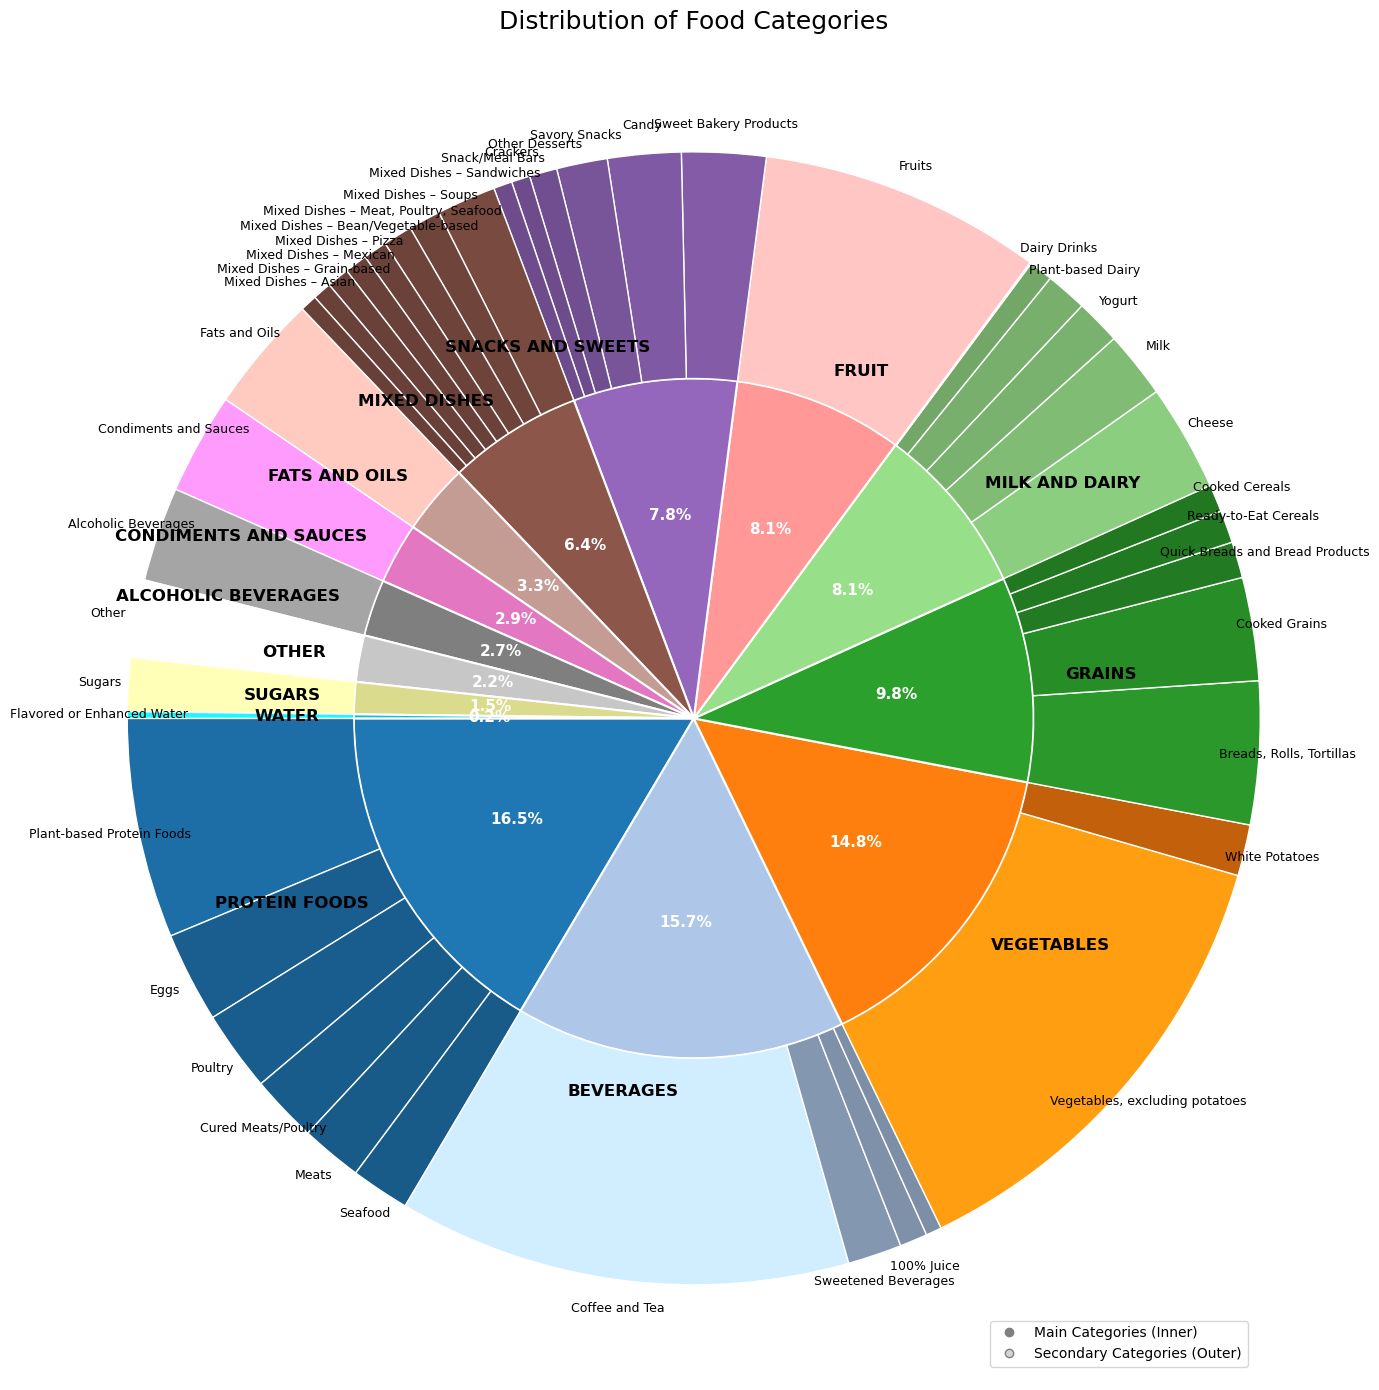

In [38]:
def plot_nested_pie_chart(df, max_secondary_per_main=4):
    """
    Create a nested pie chart with main categories in the inner circle
    and secondary categories in the outer ring
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.colors import to_rgba
    
    # Get main category counts
    main_counts = df['main_category'].value_counts()
    
    # Get secondary category counts within each main category
    grouped = df.groupby(['main_category', 'secondary_category']).size().reset_index(name='count')
    
    # Convert to dictionary of main category -> {secondary category -> count}
    nested_data = {}
    for main_cat in main_counts.index:
        # Get all secondary categories for this main category
        secondary_data = grouped[grouped['main_category'] == main_cat]
        
        # Sort by count descending
        secondary_data = secondary_data.sort_values('count', ascending=False)
        
        # Take top N categories, group the rest as "..."
        if len(secondary_data) > max_secondary_per_main:
            top_secondary = secondary_data.iloc[:max_secondary_per_main]
            other_count = secondary_data.iloc[max_secondary_per_main:]['count'].sum()
            
            # Add "..." category if it has significant count
            if other_count > 0:
                other_row = pd.DataFrame({
                    'main_category': [main_cat],
                    'secondary_category': ['...'],
                    'count': [other_count]
                })
                top_secondary = pd.concat([top_secondary, other_row])
        else:
            top_secondary = secondary_data
        
        # Store in dictionary
        nested_data[main_cat] = {row['secondary_category']: row['count'] for _, row in top_secondary.iterrows()}
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 14))
    
    # Define color map for main categories
    import matplotlib.cm as cm
    main_cmap = cm.get_cmap('tab20')
    main_colors = [main_cmap(i/len(main_counts)) for i in range(len(main_counts))]
    
    # Plot inner pie (main categories) with no explode or very minimal
    inner_wedges, inner_texts, autotexts = ax.pie(
        main_counts,
        labels=main_counts.index,
        autopct='%1.1f%%',
        radius=0.6,  # Inner pie is smaller
        startangle=180,
        wedgeprops={'edgecolor': 'w', 'linewidth': 1.5},
        textprops={'fontsize': 12, 'weight': 'bold'},
        colors=main_colors,
        explode=[0.0] * len(main_counts)  # No explode to keep alignment with outer ring
    )
    
    # Adjust opacity of percentage text for better visibility
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_weight('bold')
        autotext.set_fontsize(11)
    
    # Collect data for outer pie
    outer_data = []
    outer_labels = []
    outer_colors = []
    
    # Keep track of the start angle for each category
    start_angle = 180
    
    # For each main category
    for i, (main_cat, main_count) in enumerate(main_counts.items()):
        # Get secondary categories for this main category
        secondary_categories = nested_data[main_cat]
        
        # Calculate proportions of this main category in the whole
        main_proportion = main_count / main_counts.sum()
        
        # Calculate how many degrees this main category spans
        main_angle = main_proportion * 360
        
        # For each secondary category in this main category
        for secondary_cat, secondary_count in secondary_categories.items():
            # Calculate proportion within this main category
            secondary_proportion = secondary_count / main_count
            
            # Add to outer data
            outer_data.append(secondary_count)
            
            # Add label (only for non-tiny wedges)
            if secondary_proportion > 0.05:  # Only label if at least 5% of main category
                outer_labels.append(secondary_cat)
            else:
                outer_labels.append('')
            
            # Create color based on main category color but with variation
            base_color = main_colors[i]
            # Randomize the color slightly while maintaining the same hue
            r, g, b, a = to_rgba(base_color)
            # Make secondary wedges slightly lighter/darker than main
            variation = 0.7 + 0.6 * secondary_proportion  # Varies color by size
            r = min(1, r * variation)
            g = min(1, g * variation)
            b = min(1, b * variation)
            outer_colors.append((r, g, b, a))
        
        # Update start angle for next main category
        start_angle += main_angle
    
    # Plot outer pie (secondary categories)
    outer_wedges, outer_texts = ax.pie(
        outer_data,
        labels=outer_labels,
        radius=1.0,  # Outer pie uses full radius
        startangle=180,
        wedgeprops={'edgecolor': 'w', 'linewidth': 1.0, 'width': 0.4},  # Width creates the ring effect
        textprops={'fontsize': 9},
        labeldistance=1.05,
        colors=outer_colors
    )
    
    # Rotate outer wedge labels for better readability
    for text in outer_texts:
        text.set_horizontalalignment('center')
    
    # Add title
    plt.title('Distribution of Food Categories', fontsize=18, pad=20)
    
    # Add legend explaining the chart
    custom_lines = [
        plt.Line2D([0], [0], color='gray', lw=0, marker='o', markerfacecolor='gray'),
        plt.Line2D([0], [0], color='gray', lw=0, marker='o', markerfacecolor='lightgray')
    ]
    plt.legend(custom_lines, ['Main Categories (Inner)', 'Secondary Categories (Outer)'], 
              loc='upper right', bbox_to_anchor=(0.95, 0.05))
    
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
    plt.tight_layout()
    plt.show()
    
    return nested_data  # Return processed data for further analysis

# Create the nested pie chart
nested_data = plot_nested_pie_chart(user_food_df, max_secondary_per_main=10)

/var/folders/dv/lndb9rrs2kv2v5g8cyfyx0wr0000gn/T/ipykernel_75865/3550406555.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




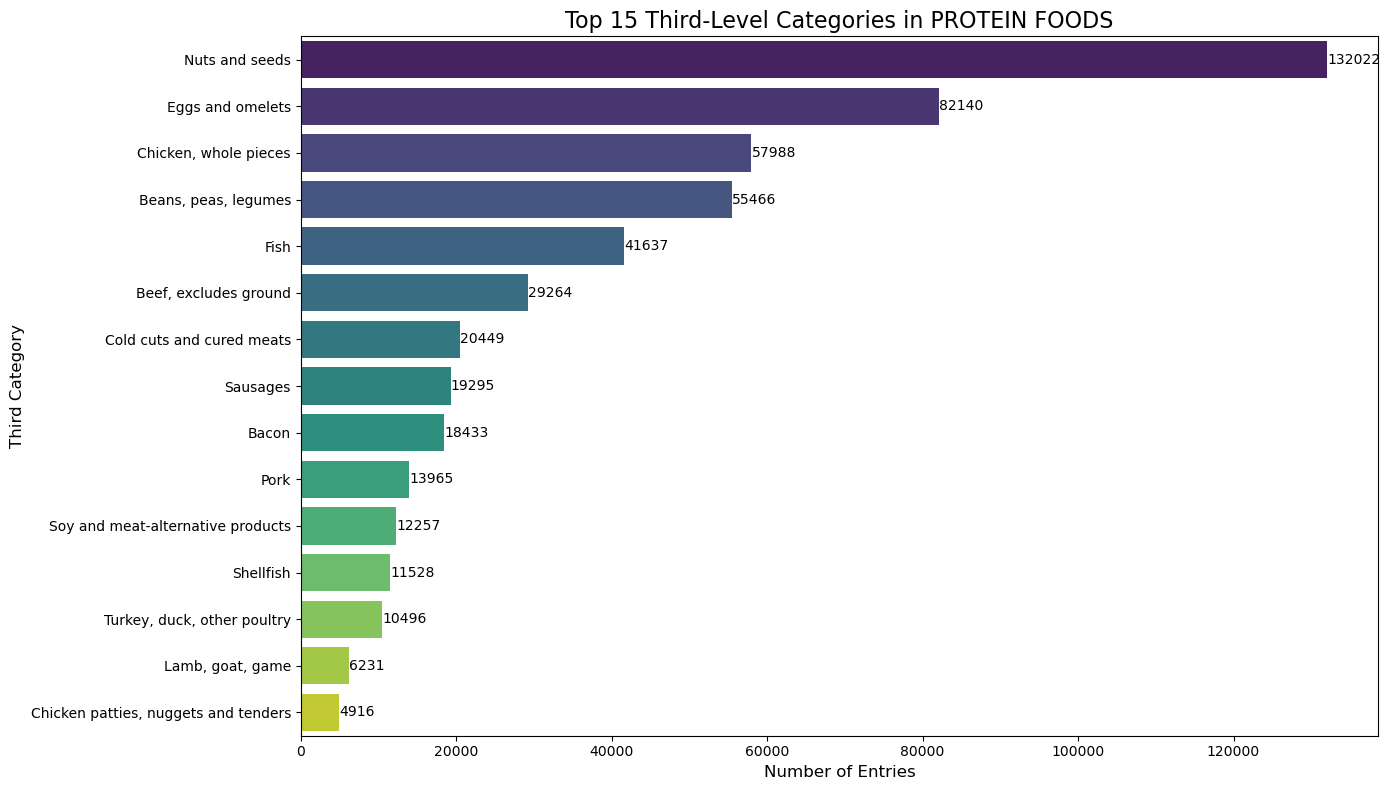

third_category
Nuts and seeds               132022
Eggs and omelets              82140
Chicken, whole pieces         57988
Beans, peas, legumes          55466
Fish                          41637
Beef, excludes ground         29264
Cold cuts and cured meats     20449
Sausages                      19295
Bacon                         18433
Pork                          13965
Name: count, dtype: int64


In [39]:
def plot_third_categories(df, main_category, secondary_category=None, top_n=15):
    """
    Visualize the distribution of third-level categories within a main (and optional secondary) category
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Filter by main category
    filtered_df = df[df['main_category'] == main_category]
    
    # Further filter by secondary category if specified
    if secondary_category:
        filtered_df = filtered_df[filtered_df['secondary_category'] == secondary_category]
        title = f'Top {top_n} Third-Level Categories in {main_category} - {secondary_category}'
    else:
        title = f'Top {top_n} Third-Level Categories in {main_category}'
    
    # Get counts of third-level categories
    third_counts = filtered_df['third_category'].value_counts().nlargest(top_n)
    
    # Create bar chart
    plt.figure(figsize=(14, 8))
    ax = sns.barplot(x=third_counts.values, y=third_counts.index, palette='viridis')
    
    # Add count labels
    for i, count in enumerate(third_counts):
        ax.text(count + 10, i, str(count), va='center')
    
    plt.title(title, fontsize=16)
    plt.xlabel('Number of Entries', fontsize=12)
    plt.ylabel('Third Category', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return third_counts  # Return for further analysis if needed

# Analyze third-level categories in PROTEIN FOODS
third_counts = plot_third_categories(user_food_df, main_category="PROTEIN FOODS")
print(third_counts.head(10))

# Uncomment to analyze a specific secondary category
# third_counts_plant = plot_third_categories(
#     user_food_df, 
#     main_category="PROTEIN FOODS", 
#     secondary_category="Plant-based Protein Foods"
# )
# print(third_counts_plant.head(10))

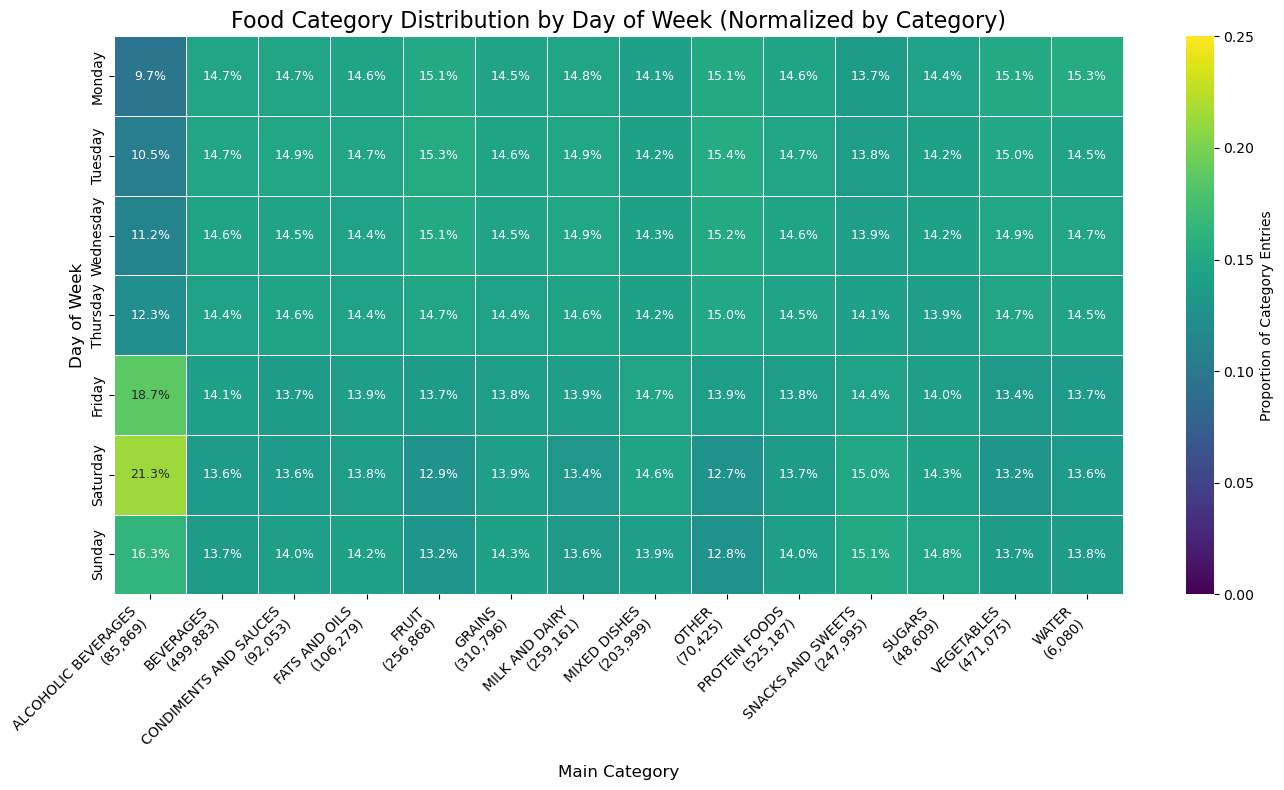

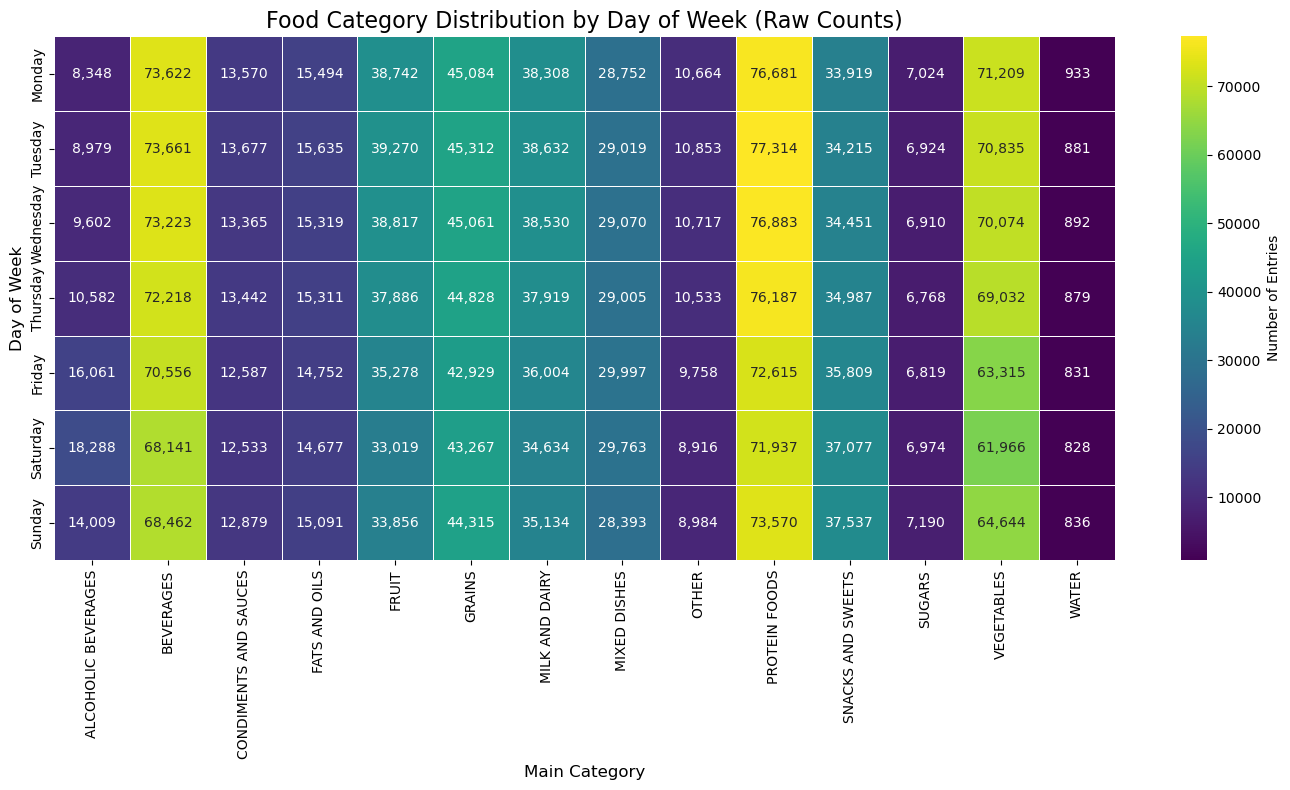

In [40]:
def plot_day_of_week(df):
    """Analyze and visualize food category distribution by day of week, normalized by category"""
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    
    # Extract day of week if timestamp is available
    if 'day_of_week' not in df.columns:
        df = df.copy()
        if 'original_logtime' in df.columns:
            df['day_of_week'] = pd.to_datetime(df['original_logtime']).dt.dayofweek
    
    if 'day_of_week' in df.columns:
        # Get counts by day and category
        day_cat_counts = df.groupby(['day_of_week', 'main_category']).size().unstack(fill_value=0)
        
        # Get day names
        day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        day_cat_counts.index = [day_names[i] for i in day_cat_counts.index]
        
        # Calculate total counts per category for labels
        category_totals = day_cat_counts.sum(axis=0)
        
        # Normalize each category (column) to show relative distribution by day
        # Each column will sum to 1 (or 100%)
        normalized_counts = day_cat_counts.div(day_cat_counts.sum(axis=0), axis=1)
        
        # Create a figure for the normalized heatmap
        plt.figure(figsize=(14, 8))
        
        # Format the annotation text - convert to percentage and round
        def pct_format(x):
            return f"{x*100:.1f}%" if x > 0.03 else ""  # Only show values above 3%
        
        # Plot the normalized heatmap using viridis colormap
        ax = sns.heatmap(
            normalized_counts, 
            cmap='viridis',  # Using viridis colormap
            annot=True, 
            fmt="",
            linewidths=0.5,
            cbar_kws={'label': 'Proportion of Category Entries'},
            annot_kws={'fontsize': 9},
            vmin=0, vmax=0.25  # Set scale to cap at 25% for better color differentiation
        )
        
        # Replace annotations with formatted percentages
        for i, (idx, row) in enumerate(normalized_counts.iterrows()):
            for j, val in enumerate(row):
                text = ax.texts[i * len(normalized_counts.columns) + j]
                text.set_text(pct_format(val))
        
        # Add category totals to column labels
        new_column_labels = [f"{col}\n({category_totals[col]:,})" for col in normalized_counts.columns]
        ax.set_xticklabels(new_column_labels, rotation=45, ha='right')
        
        plt.title('Food Category Distribution by Day of Week (Normalized by Category)', fontsize=16)
        plt.xlabel('Main Category', fontsize=12)
        plt.ylabel('Day of Week', fontsize=12)
        plt.tight_layout()
        plt.show()
        
        # Also create the raw counts heatmap for comparison
        plt.figure(figsize=(14, 8))
        sns.heatmap(
            day_cat_counts, 
            cmap='viridis',  # Using viridis colormap for raw counts as well
            annot=True, 
            fmt=',',  # Use comma as thousand separator
            linewidths=0.5,
            cbar_kws={'label': 'Number of Entries'}
        )
        
        plt.title('Food Category Distribution by Day of Week (Raw Counts)', fontsize=16)
        plt.xlabel('Main Category', fontsize=12)
        plt.ylabel('Day of Week', fontsize=12)
        plt.tight_layout()
        plt.show()
        
        return normalized_counts, day_cat_counts
    else:
        print("Day of week information not available in the dataframe.")
        return None, None

# Analyze food categories by day of week with normalized values
normalized_counts, raw_counts = plot_day_of_week(user_food_df)

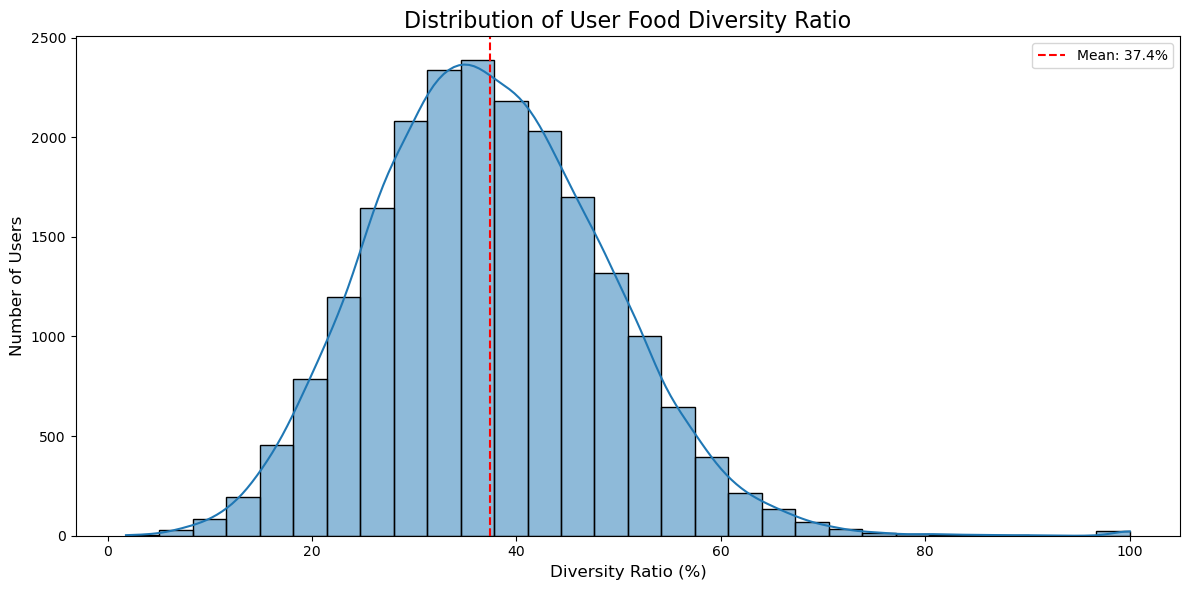

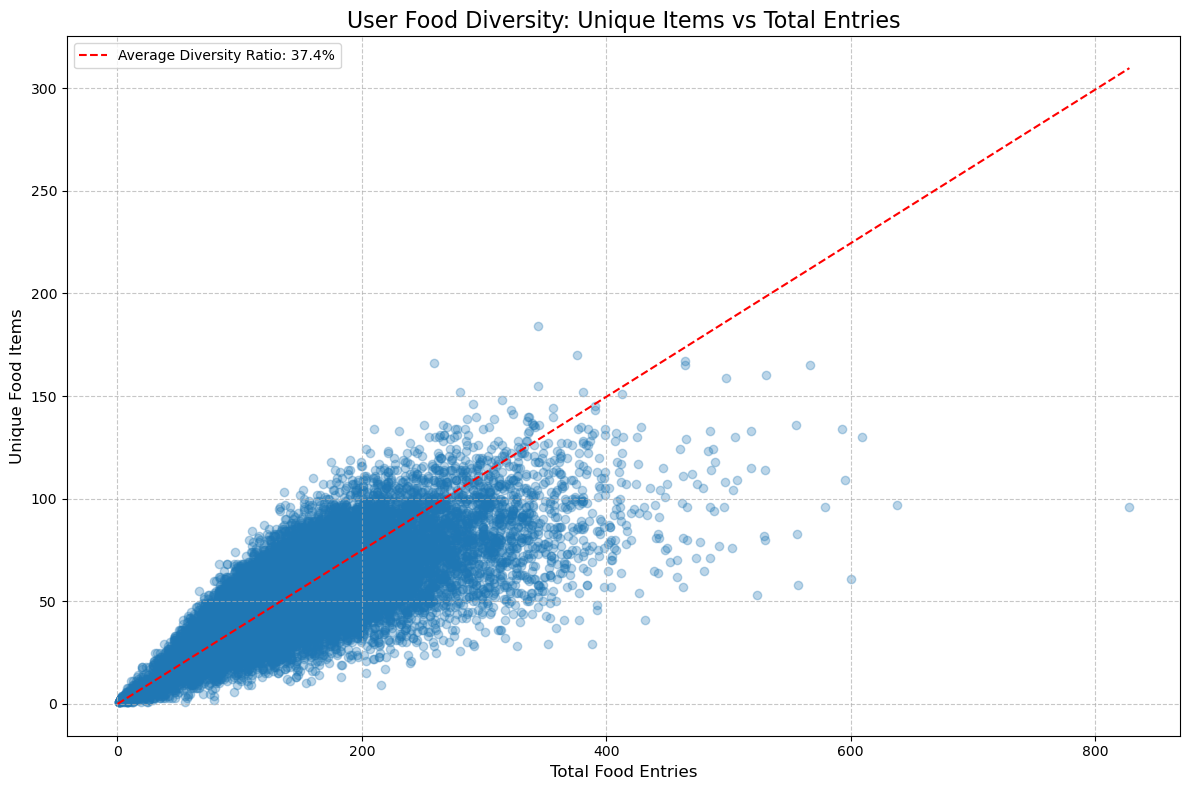

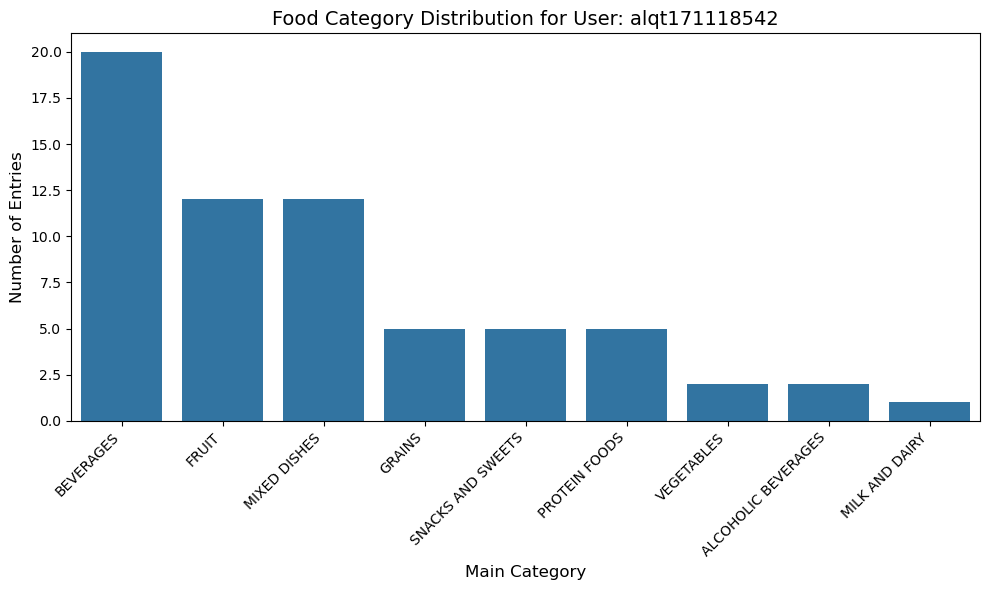

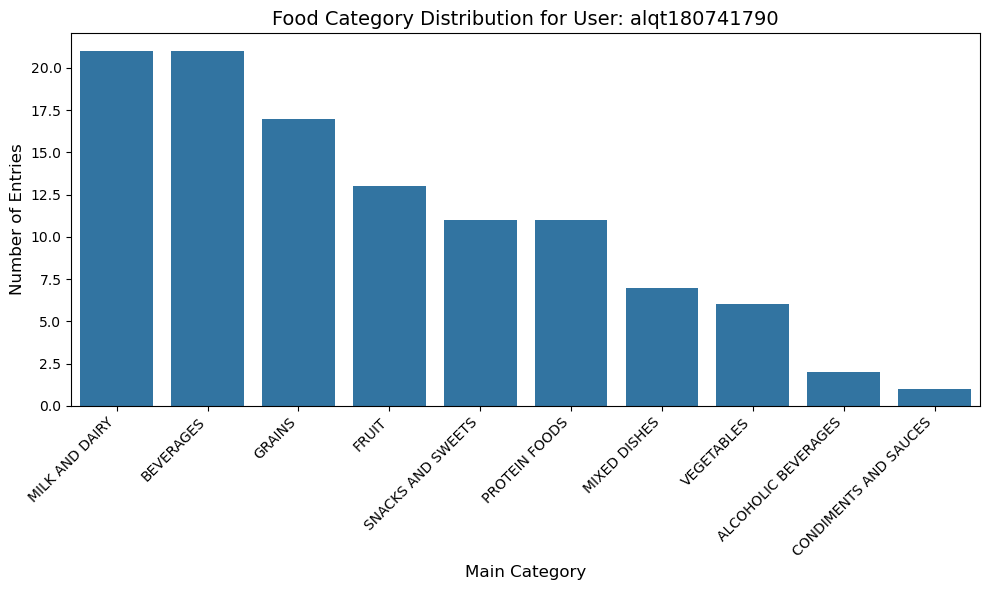

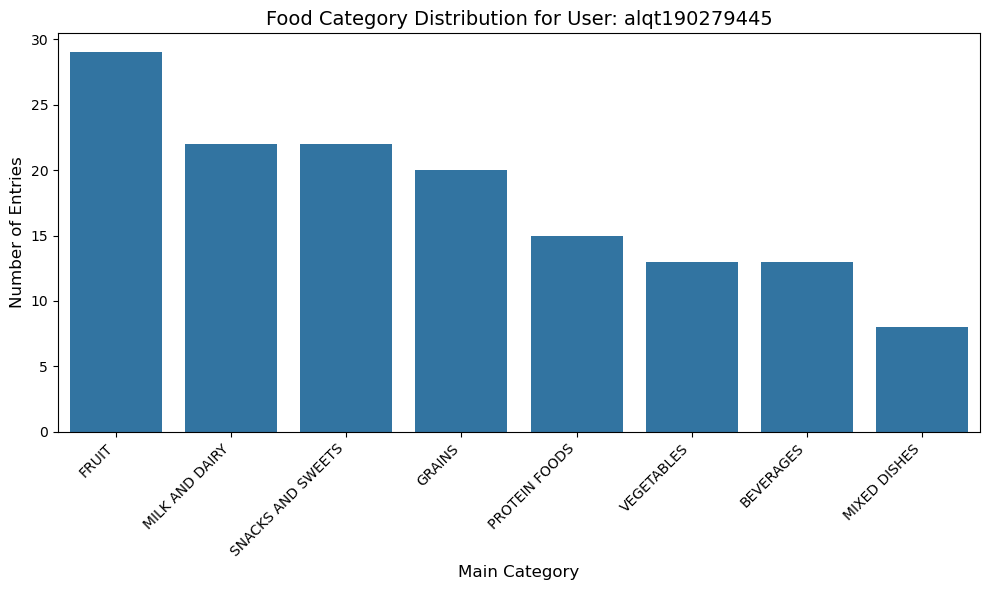

        UniqueItems  TotalEntries  DiversityRatio
count  20985.000000  20985.000000    20985.000000
mean      53.493591    151.740720       37.407015
std       22.407657     71.007983       11.494488
min        1.000000      1.000000        1.800000
25%       38.000000    103.000000       29.400000
50%       52.000000    140.000000       36.800000
75%       67.000000    188.000000       44.900000
max      184.000000    828.000000      100.000000


In [43]:
def analyze_user_diversity(df, sample_n=5):
    """
    Analyze the diversity of food choices among users
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Count unique food items per user
    user_diversity = df.groupby('pid')['food_name'].nunique()
    
    # Count total entries per user
    user_entries = df.groupby('pid').size()
    
    # Calculate diversity ratio
    user_ratio = (user_diversity / user_entries * 100).round(1)
    
    # Create summary statistics
    diversity_stats = pd.DataFrame({
        'UniqueItems': user_diversity,
        'TotalEntries': user_entries,
        'DiversityRatio': user_ratio
    })
    
    # Plot distribution of diversity ratio
    plt.figure(figsize=(12, 6))
    sns.histplot(diversity_stats['DiversityRatio'], bins=30, kde=True)
    plt.axvline(diversity_stats['DiversityRatio'].mean(), color='r', linestyle='--', 
                label=f'Mean: {diversity_stats["DiversityRatio"].mean():.1f}%')
    plt.title('Distribution of User Food Diversity Ratio', fontsize=16)
    plt.xlabel('Diversity Ratio (%)', fontsize=12)
    plt.ylabel('Number of Users', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Scatter plot of unique items vs total entries
    plt.figure(figsize=(12, 8))
    plt.scatter(diversity_stats['TotalEntries'], diversity_stats['UniqueItems'], alpha=0.3)
    plt.title('User Food Diversity: Unique Items vs Total Entries', fontsize=16)
    plt.xlabel('Total Food Entries', fontsize=12)
    plt.ylabel('Unique Food Items', fontsize=12)
    
    # Add a line for average diversity ratio
    x_range = np.linspace(0, diversity_stats['TotalEntries'].max(), 100)
    plt.plot(x_range, x_range * diversity_stats['DiversityRatio'].mean() / 100, 'r--', 
             label=f'Average Diversity Ratio: {diversity_stats["DiversityRatio"].mean():.1f}%')
    
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # Sample a few users to visualize their food category distributions
    sampled_users = np.random.choice(df['pid'].unique(), min(sample_n, len(df['pid'].unique())), replace=False)
    
    for i, user in enumerate(sampled_users):
        if i >= sample_n:  # Limit to requested number of users
            break
            
        user_df = df[df['pid'] == user]
        cat_counts = user_df['main_category'].value_counts()
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x=cat_counts.index, y=cat_counts.values)
        plt.title(f'Food Category Distribution for User: {user}', fontsize=14)
        plt.xlabel('Main Category', fontsize=12)
        plt.ylabel('Number of Entries', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    
    return diversity_stats  # Return for further analysis if needed

# Analyze user diversity (limit to 3 user samples for brevity)
user_stats = analyze_user_diversity(user_food_df, sample_n=3)
print(user_stats.describe())